In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cole's code 
## simulate data based on race

FARA = pd.read_csv ('../data/FARA.csv')
FARA = FARA[FARA['State'] == 'Arizona']
PLACES2020 = pd.read_csv('../data/PLACES.csv')
PLACES2020 = PLACES2020[PLACES2020['StateAbbr'] == 'AZ']
Columns_to_extract = ['CensusTract','TractWhite','TractBlack','TractAsian','TractNHOPI','TractAIAN','TractOMultir','TractHispanic']
PLACES_Columns_to_extract = ['OBESITY_CrudePrev','DIABETES_CrudePrev','TractFIPS','CountyName']
PLACES2020_Race = PLACES2020[PLACES_Columns_to_extract]
FARA_IMP = FARA[Columns_to_extract]
FARA_IMP = FARA_IMP.rename(columns = {'CensusTract' : 'TractFIPS'})
FARA_IMP = FARA_IMP.groupby('TractFIPS').sum()
Merged_By_Race = pd.merge(PLACES2020_Race, FARA_IMP, on = 'TractFIPS', how = 'left')
Merged_By_Race['WhiteDiabetes'] = Merged_By_Race['TractWhite'] * Merged_By_Race['DIABETES_CrudePrev']/100
Merged_By_Race['WhiteObesity'] = Merged_By_Race['TractWhite'] * Merged_By_Race['OBESITY_CrudePrev']/100
Merged_By_Race['WhiteNoDiabetes'] = Merged_By_Race['TractWhite'] * (100-Merged_By_Race['DIABETES_CrudePrev'])/100
Merged_By_Race['WhiteNoObesity'] = Merged_By_Race['TractWhite'] * (100-Merged_By_Race['OBESITY_CrudePrev'])/100
Merged_By_Race['BlackDiabetes'] = Merged_By_Race['TractBlack'] * Merged_By_Race['DIABETES_CrudePrev']/100
Merged_By_Race['BlackObesity'] = Merged_By_Race['TractBlack'] * Merged_By_Race['OBESITY_CrudePrev']/100
Merged_By_Race['BlackNoDiabetes'] = Merged_By_Race['TractBlack'] * (100-Merged_By_Race['DIABETES_CrudePrev'])/100
Merged_By_Race['BlackNoObesity'] = Merged_By_Race['TractBlack'] * (100-Merged_By_Race['OBESITY_CrudePrev'])/100
Merged_By_Race['AsianDiabetes'] = Merged_By_Race['TractAsian'] * Merged_By_Race['DIABETES_CrudePrev']/100
Merged_By_Race['AsianObesity'] = Merged_By_Race['TractAsian'] * Merged_By_Race['OBESITY_CrudePrev']/100
Merged_By_Race['AsianNoDiabetes'] = Merged_By_Race['TractAsian'] * (100-Merged_By_Race['DIABETES_CrudePrev'])/100
Merged_By_Race['AsianNoObesity'] = Merged_By_Race['TractAsian'] * (100-Merged_By_Race['OBESITY_CrudePrev'])/100
Merged_By_Race['NHOPIDiabetes'] = Merged_By_Race['TractNHOPI'] * Merged_By_Race['DIABETES_CrudePrev']/100
Merged_By_Race['NHOPIObesity'] = Merged_By_Race['TractNHOPI'] * Merged_By_Race['OBESITY_CrudePrev']/100
Merged_By_Race['NHOPINoDiabetes'] = Merged_By_Race['TractNHOPI'] * (100-Merged_By_Race['DIABETES_CrudePrev'])/100
Merged_By_Race['NHOPINoObesity'] = Merged_By_Race['TractNHOPI'] * (100-Merged_By_Race['OBESITY_CrudePrev'])/100
Merged_By_Race['AIANDiabetes'] = Merged_By_Race['TractAIAN'] * Merged_By_Race['DIABETES_CrudePrev']/100
Merged_By_Race['AIANObesity'] = Merged_By_Race['TractAIAN'] * Merged_By_Race['OBESITY_CrudePrev']/100
Merged_By_Race['AIANNoDiabetes'] = Merged_By_Race['TractAIAN'] * (100-Merged_By_Race['DIABETES_CrudePrev'])/100
Merged_By_Race['AIANNoObesity'] = Merged_By_Race['TractAIAN'] * (100-Merged_By_Race['OBESITY_CrudePrev'])/100
Merged_By_Race['OMultirDiabetes'] = Merged_By_Race['TractOMultir'] * Merged_By_Race['DIABETES_CrudePrev']/100
Merged_By_Race['OMultirObesity'] = Merged_By_Race['TractOMultir'] * Merged_By_Race['OBESITY_CrudePrev']/100
Merged_By_Race['OMultirNoDiabetes'] = Merged_By_Race['TractOMultir'] * (100-Merged_By_Race['DIABETES_CrudePrev'])/100
Merged_By_Race['OMultirNoObesity'] = Merged_By_Race['TractOMultir'] * (100-Merged_By_Race['OBESITY_CrudePrev'])/100
Merged_By_Race['HispanicDiabetes'] = Merged_By_Race['TractHispanic'] * Merged_By_Race['DIABETES_CrudePrev']/100
Merged_By_Race['HispanicObesity'] = Merged_By_Race['TractHispanic'] * Merged_By_Race['OBESITY_CrudePrev']/100
Merged_By_Race['HispanicNoDiabetes'] = Merged_By_Race['TractHispanic'] * (100-Merged_By_Race['DIABETES_CrudePrev'])/100
Merged_By_Race['HispanicNoObesity'] = Merged_By_Race['TractHispanic'] * (100-Merged_By_Race['OBESITY_CrudePrev'])/100
Merged_By_Race = Merged_By_Race.groupby('CountyName').sum()
Merged_By_Race['%WhiteDiabetes'] = Merged_By_Race['WhiteDiabetes']/Merged_By_Race['TractWhite']
Merged_By_Race['%WhiteObesity'] = Merged_By_Race['WhiteObesity']/Merged_By_Race['TractWhite']
Merged_By_Race['%BlackDiabetes'] = Merged_By_Race['BlackDiabetes']/Merged_By_Race['TractBlack']
Merged_By_Race['%BlackObesity'] = Merged_By_Race['BlackObesity']/Merged_By_Race['TractBlack']
Merged_By_Race['%AsianDiabetes'] = Merged_By_Race['AsianDiabetes']/Merged_By_Race['TractAsian']
Merged_By_Race['%AsianObesity'] = Merged_By_Race['AsianObesity']/Merged_By_Race['TractAsian']
Merged_By_Race['%NHOPIDiabetes'] = Merged_By_Race['NHOPIDiabetes']/Merged_By_Race['TractNHOPI']
Merged_By_Race['%NHOPIObesity'] = Merged_By_Race['NHOPIObesity']/Merged_By_Race['TractNHOPI']
Merged_By_Race['%AIANDiabetes'] = Merged_By_Race['AIANDiabetes']/Merged_By_Race['TractAIAN']
Merged_By_Race['%AIANObesity'] = Merged_By_Race['AIANObesity']/Merged_By_Race['TractAIAN']
Merged_By_Race['%OMultirDiabetes'] = Merged_By_Race['OMultirDiabetes']/Merged_By_Race['TractOMultir']
Merged_By_Race['%OMultirObesity'] = Merged_By_Race['OMultirObesity']/Merged_By_Race['TractOMultir']
Merged_By_Race['%HispanicDiabetes'] = Merged_By_Race['HispanicDiabetes']/Merged_By_Race['TractHispanic']
Merged_By_Race['%HispanicObesity'] = Merged_By_Race['HispanicObesity']/Merged_By_Race['TractHispanic']
Merged_By_Race['year'] = '2020'
Merged_By_Race



PLACES2021 = pd.read_csv('../data/PLACES.csv')
PLACES2021 = PLACES2021[PLACES2021['StateAbbr'] == 'AZ']
PLACES2021_Race = PLACES2021[PLACES_Columns_to_extract]
Merged_By_Race_2021 = pd.merge(PLACES2021_Race, FARA_IMP, on = 'TractFIPS', how = 'left')
Merged_By_Race_2021['WhiteDiabetes'] = Merged_By_Race_2021['TractWhite'] * Merged_By_Race_2021['DIABETES_CrudePrev']/100
Merged_By_Race_2021['WhiteObesity'] = Merged_By_Race_2021['TractWhite'] * Merged_By_Race_2021['OBESITY_CrudePrev']/100
Merged_By_Race_2021['WhiteNoDiabetes'] = Merged_By_Race_2021['TractWhite'] * (100-Merged_By_Race_2021['DIABETES_CrudePrev'])/100
Merged_By_Race_2021['WhiteNoObesity'] = Merged_By_Race_2021['TractWhite'] * (100-Merged_By_Race_2021['OBESITY_CrudePrev'])/100
Merged_By_Race_2021['BlackDiabetes'] = Merged_By_Race_2021['TractBlack'] * Merged_By_Race_2021['DIABETES_CrudePrev']/100
Merged_By_Race_2021['BlackObesity'] = Merged_By_Race_2021['TractBlack'] * Merged_By_Race_2021['OBESITY_CrudePrev']/100
Merged_By_Race_2021['BlackNoDiabetes'] = Merged_By_Race_2021['TractBlack'] * (100-Merged_By_Race_2021['DIABETES_CrudePrev'])/100
Merged_By_Race_2021['BlackNoObesity'] = Merged_By_Race_2021['TractBlack'] * (100-Merged_By_Race_2021['OBESITY_CrudePrev'])/100
Merged_By_Race_2021['AsianDiabetes'] = Merged_By_Race_2021['TractAsian'] * Merged_By_Race_2021['DIABETES_CrudePrev']/100
Merged_By_Race_2021['AsianObesity'] = Merged_By_Race_2021['TractAsian'] * Merged_By_Race_2021['OBESITY_CrudePrev']/100
Merged_By_Race_2021['AsianNoDiabetes'] = Merged_By_Race_2021['TractAsian'] * (100-Merged_By_Race_2021['DIABETES_CrudePrev'])/100
Merged_By_Race_2021['AsianNoObesity'] = Merged_By_Race_2021['TractAsian'] * (100-Merged_By_Race_2021['OBESITY_CrudePrev'])/100
Merged_By_Race_2021['NHOPIDiabetes'] = Merged_By_Race_2021['TractNHOPI'] * Merged_By_Race_2021['DIABETES_CrudePrev']/100
Merged_By_Race_2021['NHOPIObesity'] = Merged_By_Race_2021['TractNHOPI'] * Merged_By_Race_2021['OBESITY_CrudePrev']/100
Merged_By_Race_2021['NHOPINoDiabetes'] = Merged_By_Race_2021['TractNHOPI'] * (100-Merged_By_Race_2021['DIABETES_CrudePrev'])/100
Merged_By_Race_2021['NHOPINoObesity'] = Merged_By_Race_2021['TractNHOPI'] * (100-Merged_By_Race_2021['OBESITY_CrudePrev'])/100
Merged_By_Race_2021['AIANDiabetes'] = Merged_By_Race_2021['TractAIAN'] * Merged_By_Race_2021['DIABETES_CrudePrev']/100
Merged_By_Race_2021['AIANObesity'] = Merged_By_Race_2021['TractAIAN'] * Merged_By_Race_2021['OBESITY_CrudePrev']/100
Merged_By_Race_2021['AIANNoDiabetes'] = Merged_By_Race_2021['TractAIAN'] * (100-Merged_By_Race_2021['DIABETES_CrudePrev'])/100
Merged_By_Race_2021['AIANNoObesity'] = Merged_By_Race_2021['TractAIAN'] * (100-Merged_By_Race_2021['OBESITY_CrudePrev'])/100
Merged_By_Race_2021['OMultirDiabetes'] = Merged_By_Race_2021['TractOMultir'] * Merged_By_Race_2021['DIABETES_CrudePrev']/100
Merged_By_Race_2021['OMultirObesity'] = Merged_By_Race_2021['TractOMultir'] * Merged_By_Race_2021['OBESITY_CrudePrev']/100
Merged_By_Race_2021['OMultirNoDiabetes'] = Merged_By_Race_2021['TractOMultir'] * (100-Merged_By_Race_2021['DIABETES_CrudePrev'])/100
Merged_By_Race_2021['OMultirNoObesity'] = Merged_By_Race_2021['TractOMultir'] * (100-Merged_By_Race_2021['OBESITY_CrudePrev'])/100
Merged_By_Race_2021['HispanicDiabetes'] = Merged_By_Race_2021['TractHispanic'] * Merged_By_Race_2021['DIABETES_CrudePrev']/100
Merged_By_Race_2021['HispanicObesity'] = Merged_By_Race_2021['TractHispanic'] * Merged_By_Race_2021['OBESITY_CrudePrev']/100
Merged_By_Race_2021['HispanicNoDiabetes'] = Merged_By_Race_2021['TractHispanic'] * (100-Merged_By_Race_2021['DIABETES_CrudePrev'])/100
Merged_By_Race_2021['HispanicNoObesity'] = Merged_By_Race_2021['TractHispanic'] * (100-Merged_By_Race_2021['OBESITY_CrudePrev'])/100
Merged_By_Race_2021 = Merged_By_Race_2021.groupby('CountyName').sum()
Merged_By_Race_2021['%WhiteDiabetes'] = Merged_By_Race_2021['WhiteDiabetes']/Merged_By_Race_2021['TractWhite']
Merged_By_Race_2021['%WhiteObesity'] = Merged_By_Race_2021['WhiteObesity']/Merged_By_Race_2021['TractWhite']
Merged_By_Race_2021['%BlackDiabetes'] = Merged_By_Race_2021['BlackDiabetes']/Merged_By_Race_2021['TractBlack']
Merged_By_Race_2021['%BlackObesity'] = Merged_By_Race_2021['BlackObesity']/Merged_By_Race_2021['TractBlack']
Merged_By_Race_2021['%AsianDiabetes'] = Merged_By_Race_2021['AsianDiabetes']/Merged_By_Race_2021['TractAsian']
Merged_By_Race_2021['%AsianObesity'] = Merged_By_Race_2021['AsianObesity']/Merged_By_Race_2021['TractAsian']
Merged_By_Race_2021['%NHOPIDiabetes'] = Merged_By_Race_2021['NHOPIDiabetes']/Merged_By_Race_2021['TractNHOPI']
Merged_By_Race_2021['%NHOPIObesity'] = Merged_By_Race_2021['NHOPIObesity']/Merged_By_Race_2021['TractNHOPI']
Merged_By_Race_2021['%AIANDiabetes'] = Merged_By_Race_2021['AIANDiabetes']/Merged_By_Race_2021['TractAIAN']
Merged_By_Race_2021['%AIANObesity'] = Merged_By_Race_2021['AIANObesity']/Merged_By_Race_2021['TractAIAN']
Merged_By_Race_2021['%OMultirDiabetes'] = Merged_By_Race_2021['OMultirDiabetes']/Merged_By_Race_2021['TractOMultir']
Merged_By_Race_2021['%OMultirObesity'] = Merged_By_Race_2021['OMultirObesity']/Merged_By_Race_2021['TractOMultir']
Merged_By_Race_2021['%HispanicDiabetes'] = Merged_By_Race_2021['HispanicDiabetes']/Merged_By_Race_2021['TractHispanic']
Merged_By_Race_2021['%HispanicObesity'] = Merged_By_Race_2021['HispanicObesity']/Merged_By_Race_2021['TractHispanic']
Merged_By_Race_2021['year'] = '2021'
Merged_By_Race_2021


PLACES2022 = pd.read_csv('../data/PLACES.csv')
PLACES2022 = PLACES2022[PLACES2022['StateAbbr'] == 'AZ']
PLACES2022_Race = PLACES2022[PLACES_Columns_to_extract]
Merged_By_Race_2022 = pd.merge(PLACES2020_Race, FARA_IMP, on = 'TractFIPS', how = 'left')
Merged_By_Race_2022['WhiteDiabetes'] = Merged_By_Race_2022['TractWhite'] * Merged_By_Race_2022['DIABETES_CrudePrev']/100
Merged_By_Race_2022['WhiteObesity'] = Merged_By_Race_2022['TractWhite'] * Merged_By_Race_2022['OBESITY_CrudePrev']/100
Merged_By_Race_2022['WhiteNoDiabetes'] = Merged_By_Race_2022['TractWhite'] * (100-Merged_By_Race_2022['DIABETES_CrudePrev'])/100
Merged_By_Race_2022['WhiteNoObesity'] = Merged_By_Race_2022['TractWhite'] * (100-Merged_By_Race_2022['OBESITY_CrudePrev'])/100
Merged_By_Race_2022['BlackDiabetes'] = Merged_By_Race_2022['TractBlack'] * Merged_By_Race_2022['DIABETES_CrudePrev']/100
Merged_By_Race_2022['BlackObesity'] = Merged_By_Race_2022['TractBlack'] * Merged_By_Race_2022['OBESITY_CrudePrev']/100
Merged_By_Race_2022['BlackNoDiabetes'] = Merged_By_Race_2022['TractBlack'] * (100-Merged_By_Race_2022['DIABETES_CrudePrev'])/100
Merged_By_Race_2022['BlackNoObesity'] = Merged_By_Race_2022['TractBlack'] * (100-Merged_By_Race_2022['OBESITY_CrudePrev'])/100
Merged_By_Race_2022['AsianDiabetes'] = Merged_By_Race_2022['TractAsian'] * Merged_By_Race_2022['DIABETES_CrudePrev']/100
Merged_By_Race_2022['AsianObesity'] = Merged_By_Race_2022['TractAsian'] * Merged_By_Race_2022['OBESITY_CrudePrev']/100
Merged_By_Race_2022['AsianNoDiabetes'] = Merged_By_Race_2022['TractAsian'] * (100-Merged_By_Race_2022['DIABETES_CrudePrev'])/100
Merged_By_Race_2022['AsianNoObesity'] = Merged_By_Race_2022['TractAsian'] * (100-Merged_By_Race_2022['OBESITY_CrudePrev'])/100
Merged_By_Race_2022['NHOPIDiabetes'] = Merged_By_Race_2022['TractNHOPI'] * Merged_By_Race_2022['DIABETES_CrudePrev']/100
Merged_By_Race_2022['NHOPIObesity'] = Merged_By_Race_2022['TractNHOPI'] * Merged_By_Race_2022['OBESITY_CrudePrev']/100
Merged_By_Race_2022['NHOPINoDiabetes'] = Merged_By_Race_2022['TractNHOPI'] * (100-Merged_By_Race_2022['DIABETES_CrudePrev'])/100
Merged_By_Race_2022['NHOPINoObesity'] = Merged_By_Race_2022['TractNHOPI'] * (100-Merged_By_Race_2022['OBESITY_CrudePrev'])/100
Merged_By_Race_2022['AIANDiabetes'] = Merged_By_Race_2022['TractAIAN'] * Merged_By_Race_2022['DIABETES_CrudePrev']/100
Merged_By_Race_2022['AIANObesity'] = Merged_By_Race_2022['TractAIAN'] * Merged_By_Race_2022['OBESITY_CrudePrev']/100
Merged_By_Race_2022['AIANNoDiabetes'] = Merged_By_Race_2022['TractAIAN'] * (100-Merged_By_Race_2022['DIABETES_CrudePrev'])/100
Merged_By_Race_2022['AIANNoObesity'] = Merged_By_Race_2022['TractAIAN'] * (100-Merged_By_Race_2022['OBESITY_CrudePrev'])/100
Merged_By_Race_2022['OMultirDiabetes'] = Merged_By_Race_2022['TractOMultir'] * Merged_By_Race_2022['DIABETES_CrudePrev']/100
Merged_By_Race_2022['OMultirObesity'] = Merged_By_Race_2022['TractOMultir'] * Merged_By_Race_2022['OBESITY_CrudePrev']/100
Merged_By_Race_2022['OMultirNoDiabetes'] = Merged_By_Race_2022['TractOMultir'] * (100-Merged_By_Race_2022['DIABETES_CrudePrev'])/100
Merged_By_Race_2022['OMultirNoObesity'] = Merged_By_Race_2022['TractOMultir'] * (100-Merged_By_Race_2022['OBESITY_CrudePrev'])/100
Merged_By_Race_2022['HispanicDiabetes'] = Merged_By_Race_2022['TractHispanic'] * Merged_By_Race_2022['DIABETES_CrudePrev']/100
Merged_By_Race_2022['HispanicObesity'] = Merged_By_Race_2022['TractHispanic'] * Merged_By_Race_2022['OBESITY_CrudePrev']/100
Merged_By_Race_2022['HispanicNoDiabetes'] = Merged_By_Race_2022['TractHispanic'] * (100-Merged_By_Race_2022['DIABETES_CrudePrev'])/100
Merged_By_Race_2022['HispanicNoObesity'] = Merged_By_Race_2022['TractHispanic'] * (100-Merged_By_Race_2022['OBESITY_CrudePrev'])/100
Merged_By_Race_2022 = Merged_By_Race_2022.groupby('CountyName').sum()
Merged_By_Race_2022['%WhiteDiabetes'] = Merged_By_Race_2022['WhiteDiabetes']/Merged_By_Race_2022['TractWhite']
Merged_By_Race_2022['%WhiteObesity'] = Merged_By_Race_2022['WhiteObesity']/Merged_By_Race_2022['TractWhite']
Merged_By_Race_2022['%BlackDiabetes'] = Merged_By_Race_2022['BlackDiabetes']/Merged_By_Race_2022['TractBlack']
Merged_By_Race_2022['%BlackObesity'] = Merged_By_Race_2022['BlackObesity']/Merged_By_Race_2022['TractBlack']
Merged_By_Race_2022['%AsianDiabetes'] = Merged_By_Race_2022['AsianDiabetes']/Merged_By_Race_2022['TractAsian']
Merged_By_Race_2022['%AsianObesity'] = Merged_By_Race_2022['AsianObesity']/Merged_By_Race_2022['TractAsian']
Merged_By_Race_2022['%NHOPIDiabetes'] = Merged_By_Race_2022['NHOPIDiabetes']/Merged_By_Race_2022['TractNHOPI']
Merged_By_Race_2022['%NHOPIObesity'] = Merged_By_Race_2022['NHOPIObesity']/Merged_By_Race_2022['TractNHOPI']
Merged_By_Race_2022['%AIANDiabetes'] = Merged_By_Race_2022['AIANDiabetes']/Merged_By_Race_2022['TractAIAN']
Merged_By_Race_2022['%AIANObesity'] = Merged_By_Race_2022['AIANObesity']/Merged_By_Race_2022['TractAIAN']
Merged_By_Race_2022['%OMultirDiabetes'] = Merged_By_Race_2022['OMultirDiabetes']/Merged_By_Race_2022['TractOMultir']
Merged_By_Race_2022['%OMultirObesity'] = Merged_By_Race_2022['OMultirObesity']/Merged_By_Race_2022['TractOMultir']
Merged_By_Race_2022['%HispanicDiabetes'] = Merged_By_Race_2022['HispanicDiabetes']/Merged_By_Race_2022['TractHispanic']
Merged_By_Race_2022['%HispanicObesity'] = Merged_By_Race_2022['HispanicObesity']/Merged_By_Race_2022['TractHispanic']
Merged_By_Race_2022['year'] = '2022'
Merged_By_Race_2022

PLACES2023 = pd.read_csv('../data/PLACES.csv')
PLACES2023 = PLACES2023[PLACES2023['StateAbbr'] == 'AZ']
PLACES2023_Race = PLACES2023[PLACES_Columns_to_extract]
Merged_By_Race_2023 = pd.merge(PLACES2020_Race, FARA_IMP, on = 'TractFIPS', how = 'left')
Merged_By_Race_2023['WhiteDiabetes'] = Merged_By_Race_2023['TractWhite'] * Merged_By_Race_2023['DIABETES_CrudePrev']/100
Merged_By_Race_2023['WhiteObesity'] = Merged_By_Race_2023['TractWhite'] * Merged_By_Race_2023['OBESITY_CrudePrev']/100
Merged_By_Race_2023['WhiteNoDiabetes'] = Merged_By_Race_2023['TractWhite'] * (100-Merged_By_Race_2023['DIABETES_CrudePrev'])/100
Merged_By_Race_2023['WhiteNoObesity'] = Merged_By_Race_2023['TractWhite'] * (100-Merged_By_Race_2023['OBESITY_CrudePrev'])/100
Merged_By_Race_2023['BlackDiabetes'] = Merged_By_Race_2023['TractBlack'] * Merged_By_Race_2023['DIABETES_CrudePrev']/100
Merged_By_Race_2023['BlackObesity'] = Merged_By_Race_2023['TractBlack'] * Merged_By_Race_2023['OBESITY_CrudePrev']/100
Merged_By_Race_2023['BlackNoDiabetes'] = Merged_By_Race_2023['TractBlack'] * (100-Merged_By_Race_2023['DIABETES_CrudePrev'])/100
Merged_By_Race_2023['BlackNoObesity'] = Merged_By_Race_2023['TractBlack'] * (100-Merged_By_Race_2023['OBESITY_CrudePrev'])/100
Merged_By_Race_2023['AsianDiabetes'] = Merged_By_Race_2023['TractAsian'] * Merged_By_Race_2023['DIABETES_CrudePrev']/100
Merged_By_Race_2023['AsianObesity'] = Merged_By_Race_2023['TractAsian'] * Merged_By_Race_2023['OBESITY_CrudePrev']/100
Merged_By_Race_2023['AsianNoDiabetes'] = Merged_By_Race_2023['TractAsian'] * (100-Merged_By_Race_2023['DIABETES_CrudePrev'])/100
Merged_By_Race_2023['AsianNoObesity'] = Merged_By_Race_2023['TractAsian'] * (100-Merged_By_Race_2023['OBESITY_CrudePrev'])/100
Merged_By_Race_2023['NHOPIDiabetes'] = Merged_By_Race_2023['TractNHOPI'] * Merged_By_Race_2023['DIABETES_CrudePrev']/100
Merged_By_Race_2023['NHOPIObesity'] = Merged_By_Race_2023['TractNHOPI'] * Merged_By_Race_2023['OBESITY_CrudePrev']/100
Merged_By_Race_2023['NHOPINoDiabetes'] = Merged_By_Race_2023['TractNHOPI'] * (100-Merged_By_Race_2023['DIABETES_CrudePrev'])/100
Merged_By_Race_2023['NHOPINoObesity'] = Merged_By_Race_2023['TractNHOPI'] * (100-Merged_By_Race_2023['OBESITY_CrudePrev'])/100
Merged_By_Race_2023['AIANDiabetes'] = Merged_By_Race_2023['TractAIAN'] * Merged_By_Race_2023['DIABETES_CrudePrev']/100
Merged_By_Race_2023['AIANObesity'] = Merged_By_Race_2023['TractAIAN'] * Merged_By_Race_2023['OBESITY_CrudePrev']/100
Merged_By_Race_2023['AIANNoDiabetes'] = Merged_By_Race_2023['TractAIAN'] * (100-Merged_By_Race_2023['DIABETES_CrudePrev'])/100
Merged_By_Race_2023['AIANNoObesity'] = Merged_By_Race_2023['TractAIAN'] * (100-Merged_By_Race_2023['OBESITY_CrudePrev'])/100
Merged_By_Race_2023['OMultirDiabetes'] = Merged_By_Race_2023['TractOMultir'] * Merged_By_Race_2023['DIABETES_CrudePrev']/100
Merged_By_Race_2023['OMultirObesity'] = Merged_By_Race_2023['TractOMultir'] * Merged_By_Race_2023['OBESITY_CrudePrev']/100
Merged_By_Race_2023['OMultirNoDiabetes'] = Merged_By_Race_2023['TractOMultir'] * (100-Merged_By_Race_2023['DIABETES_CrudePrev'])/100
Merged_By_Race_2023['OMultirNoObesity'] = Merged_By_Race_2023['TractOMultir'] * (100-Merged_By_Race_2023['OBESITY_CrudePrev'])/100
Merged_By_Race_2023['HispanicDiabetes'] = Merged_By_Race_2023['TractHispanic'] * Merged_By_Race_2023['DIABETES_CrudePrev']/100
Merged_By_Race_2023['HispanicObesity'] = Merged_By_Race_2023['TractHispanic'] * Merged_By_Race_2023['OBESITY_CrudePrev']/100
Merged_By_Race_2023['HispanicNoDiabetes'] = Merged_By_Race_2023['TractHispanic'] * (100-Merged_By_Race_2023['DIABETES_CrudePrev'])/100
Merged_By_Race_2023['HispanicNoObesity'] = Merged_By_Race_2023['TractHispanic'] * (100-Merged_By_Race_2023['OBESITY_CrudePrev'])/100
Merged_By_Race_2023 = Merged_By_Race_2023.groupby('CountyName').sum()
Merged_By_Race_2023['%WhiteDiabetes'] = Merged_By_Race_2023['WhiteDiabetes']/Merged_By_Race_2023['TractWhite']
Merged_By_Race_2023['%WhiteObesity'] = Merged_By_Race_2023['WhiteObesity']/Merged_By_Race_2023['TractWhite']
Merged_By_Race_2023['%BlackDiabetes'] = Merged_By_Race_2023['BlackDiabetes']/Merged_By_Race_2023['TractBlack']
Merged_By_Race_2023['%BlackObesity'] = Merged_By_Race_2023['BlackObesity']/Merged_By_Race_2023['TractBlack']
Merged_By_Race_2023['%AsianDiabetes'] = Merged_By_Race_2023['AsianDiabetes']/Merged_By_Race_2023['TractAsian']
Merged_By_Race_2023['%AsianObesity'] = Merged_By_Race_2023['AsianObesity']/Merged_By_Race_2023['TractAsian']
Merged_By_Race_2023['%NHOPIDiabetes'] = Merged_By_Race_2023['NHOPIDiabetes']/Merged_By_Race_2023['TractNHOPI']
Merged_By_Race_2023['%NHOPIObesity'] = Merged_By_Race_2023['NHOPIObesity']/Merged_By_Race_2023['TractNHOPI']
Merged_By_Race_2023['%AIANDiabetes'] = Merged_By_Race_2023['AIANDiabetes']/Merged_By_Race_2023['TractAIAN']
Merged_By_Race_2023['%AIANObesity'] = Merged_By_Race_2023['AIANObesity']/Merged_By_Race_2023['TractAIAN']
Merged_By_Race_2023['%OMultirDiabetes'] = Merged_By_Race_2023['OMultirDiabetes']/Merged_By_Race_2023['TractOMultir']
Merged_By_Race_2023['%OMultirObesity'] = Merged_By_Race_2023['OMultirObesity']/Merged_By_Race_2023['TractOMultir']
Merged_By_Race_2023['%HispanicDiabetes'] = Merged_By_Race_2023['HispanicDiabetes']/Merged_By_Race_2023['TractHispanic']
Merged_By_Race_2023['%HispanicObesity'] = Merged_By_Race_2023['HispanicObesity']/Merged_By_Race_2023['TractHispanic']
Merged_By_Race_2023['year'] = '2023'
Merged_By_Race_2023

PLACES2024 = pd.read_csv('../data/PLACES.csv')
PLACES2024 = PLACES2024[PLACES2024['StateAbbr'] == 'AZ']
PLACES2024_Race = PLACES2024[PLACES_Columns_to_extract]
Merged_By_Race_2024 = pd.merge(PLACES2020_Race, FARA_IMP, on = 'TractFIPS', how = 'left')
Merged_By_Race_2024['WhiteDiabetes'] = Merged_By_Race_2024['TractWhite'] * Merged_By_Race_2024['DIABETES_CrudePrev']/100
Merged_By_Race_2024['WhiteObesity'] = Merged_By_Race_2024['TractWhite'] * Merged_By_Race_2024['OBESITY_CrudePrev']/100
Merged_By_Race_2024['WhiteNoDiabetes'] = Merged_By_Race_2024['TractWhite'] * (100-Merged_By_Race_2024['DIABETES_CrudePrev'])/100
Merged_By_Race_2024['WhiteNoObesity'] = Merged_By_Race_2024['TractWhite'] * (100-Merged_By_Race_2024['OBESITY_CrudePrev'])/100
Merged_By_Race_2024['BlackDiabetes'] = Merged_By_Race_2024['TractBlack'] * Merged_By_Race_2024['DIABETES_CrudePrev']/100
Merged_By_Race_2024['BlackObesity'] = Merged_By_Race_2024['TractBlack'] * Merged_By_Race_2024['OBESITY_CrudePrev']/100
Merged_By_Race_2024['BlackNoDiabetes'] = Merged_By_Race_2024['TractBlack'] * (100-Merged_By_Race_2024['DIABETES_CrudePrev'])/100
Merged_By_Race_2024['BlackNoObesity'] = Merged_By_Race_2024['TractBlack'] * (100-Merged_By_Race_2024['OBESITY_CrudePrev'])/100
Merged_By_Race_2024['AsianDiabetes'] = Merged_By_Race_2024['TractAsian'] * Merged_By_Race_2024['DIABETES_CrudePrev']/100
Merged_By_Race_2024['AsianObesity'] = Merged_By_Race_2024['TractAsian'] * Merged_By_Race_2024['OBESITY_CrudePrev']/100
Merged_By_Race_2024['AsianNoDiabetes'] = Merged_By_Race_2024['TractAsian'] * (100-Merged_By_Race_2024['DIABETES_CrudePrev'])/100
Merged_By_Race_2024['AsianNoObesity'] = Merged_By_Race_2024['TractAsian'] * (100-Merged_By_Race_2024['OBESITY_CrudePrev'])/100
Merged_By_Race_2024['NHOPIDiabetes'] = Merged_By_Race_2024['TractNHOPI'] * Merged_By_Race_2024['DIABETES_CrudePrev']/100
Merged_By_Race_2024['NHOPIObesity'] = Merged_By_Race_2024['TractNHOPI'] * Merged_By_Race_2024['OBESITY_CrudePrev']/100
Merged_By_Race_2024['NHOPINoDiabetes'] = Merged_By_Race_2024['TractNHOPI'] * (100-Merged_By_Race_2024['DIABETES_CrudePrev'])/100
Merged_By_Race_2024['NHOPINoObesity'] = Merged_By_Race_2024['TractNHOPI'] * (100-Merged_By_Race_2024['OBESITY_CrudePrev'])/100
Merged_By_Race_2024['AIANDiabetes'] = Merged_By_Race_2024['TractAIAN'] * Merged_By_Race_2024['DIABETES_CrudePrev']/100
Merged_By_Race_2024['AIANObesity'] = Merged_By_Race_2024['TractAIAN'] * Merged_By_Race_2024['OBESITY_CrudePrev']/100
Merged_By_Race_2024['AIANNoDiabetes'] = Merged_By_Race_2024['TractAIAN'] * (100-Merged_By_Race_2024['DIABETES_CrudePrev'])/100
Merged_By_Race_2024['AIANNoObesity'] = Merged_By_Race_2024['TractAIAN'] * (100-Merged_By_Race_2024['OBESITY_CrudePrev'])/100
Merged_By_Race_2024['OMultirDiabetes'] = Merged_By_Race_2024['TractOMultir'] * Merged_By_Race_2024['DIABETES_CrudePrev']/100
Merged_By_Race_2024['OMultirObesity'] = Merged_By_Race_2024['TractOMultir'] * Merged_By_Race_2024['OBESITY_CrudePrev']/100
Merged_By_Race_2024['OMultirNoDiabetes'] = Merged_By_Race_2024['TractOMultir'] * (100-Merged_By_Race_2024['DIABETES_CrudePrev'])/100
Merged_By_Race_2024['OMultirNoObesity'] = Merged_By_Race_2024['TractOMultir'] * (100-Merged_By_Race_2024['OBESITY_CrudePrev'])/100
Merged_By_Race_2024['HispanicDiabetes'] = Merged_By_Race_2024['TractHispanic'] * Merged_By_Race_2024['DIABETES_CrudePrev']/100
Merged_By_Race_2024['HispanicObesity'] = Merged_By_Race_2024['TractHispanic'] * Merged_By_Race_2024['OBESITY_CrudePrev']/100
Merged_By_Race_2024['HispanicNoDiabetes'] = Merged_By_Race_2024['TractHispanic'] * (100-Merged_By_Race_2024['DIABETES_CrudePrev'])/100
Merged_By_Race_2024['HispanicNoObesity'] = Merged_By_Race_2024['TractHispanic'] * (100-Merged_By_Race_2024['OBESITY_CrudePrev'])/100
Merged_By_Race_2024 = Merged_By_Race_2024.groupby('CountyName').sum()
Merged_By_Race_2024['%WhiteDiabetes'] = Merged_By_Race_2024['WhiteDiabetes']/Merged_By_Race_2024['TractWhite']
Merged_By_Race_2024['%WhiteObesity'] = Merged_By_Race_2024['WhiteObesity']/Merged_By_Race_2024['TractWhite']
Merged_By_Race_2024['%BlackDiabetes'] = Merged_By_Race_2024['BlackDiabetes']/Merged_By_Race_2024['TractBlack']
Merged_By_Race_2024['%BlackObesity'] = Merged_By_Race_2024['BlackObesity']/Merged_By_Race_2024['TractBlack']
Merged_By_Race_2024['%AsianDiabetes'] = Merged_By_Race_2024['AsianDiabetes']/Merged_By_Race_2024['TractAsian']
Merged_By_Race_2024['%AsianObesity'] = Merged_By_Race_2024['AsianObesity']/Merged_By_Race_2024['TractAsian']
Merged_By_Race_2024['%NHOPIDiabetes'] = Merged_By_Race_2024['NHOPIDiabetes']/Merged_By_Race_2024['TractNHOPI']
Merged_By_Race_2024['%NHOPIObesity'] = Merged_By_Race_2024['NHOPIObesity']/Merged_By_Race_2024['TractNHOPI']
Merged_By_Race_2024['%AIANDiabetes'] = Merged_By_Race_2024['AIANDiabetes']/Merged_By_Race_2024['TractAIAN']
Merged_By_Race_2024['%AIANObesity'] = Merged_By_Race_2024['AIANObesity']/Merged_By_Race_2024['TractAIAN']
Merged_By_Race_2024['%OMultirDiabetes'] = Merged_By_Race_2024['OMultirDiabetes']/Merged_By_Race_2024['TractOMultir']
Merged_By_Race_2024['%OMultirObesity'] = Merged_By_Race_2024['OMultirObesity']/Merged_By_Race_2024['TractOMultir']
Merged_By_Race_2024['%HispanicDiabetes'] = Merged_By_Race_2024['HispanicDiabetes']/Merged_By_Race_2024['TractHispanic']
Merged_By_Race_2024['%HispanicObesity'] = Merged_By_Race_2024['HispanicObesity']/Merged_By_Race_2024['TractHispanic']
Merged_By_Race_2024['year'] = '2024'
Merged_By_Race_2024

,OBESITY_CrudePrev,DIABETES_CrudePrev,TractFIPS,TractWhite,TractBlack,TractAsian,TractNHOPI,TractAIAN,TractOMultir,TractHispanic,...,%AsianObesity,%NHOPIDiabetes,%NHOPIObesity,%AIANDiabetes,%AIANObesity,%OMultirDiabetes,%OMultirObesity,%HispanicDiabetes,%HispanicObesity,year
CountyName,,,,,,,,,,,,,,,,,,,,,
Apache,561.4,257.9,64031212512,16634.0,175.0,203.0,26.0,52154.0,2326.0,4113.0,...,0.336039,0.147077,0.332077,0.177325,0.371487,0.134515,0.319048,0.122297,0.305190,2024
Cochise,1058.5,361.9,128096034933,103085.0,5465.0,2525.0,418.0,1589.0,18264.0,42543.0,...,0.303622,0.094627,0.309742,0.112699,0.333388,0.119557,0.342408,0.126248,0.350173,2024
Coconino,731.4,251.2,112145689509,82967.0,1629.0,1846.0,164.0,36714.0,11101.0,18166.0,...,0.238820,0.066848,0.240421,0.127319,0.306835,0.074147,0.251797,0.072608,0.249858,2024
Gila,524.1,218.7,64113890003,41162.0,233.0,273.0,47.0,7946.0,3936.0,9588.0,...,0.308201,0.123681,0.305872,0.169312,0.402254,0.131876,0.322287,0.131497,0.323430,2024
Graham,304.0,98.5,36089631503,26827.0,683.0,200.0,52.0,5376.0,4082.0,11320.0,...,0.324905,0.092962,0.331981,0.162462,0.416529,0.103811,0.327229,0.104179,0.329021,2024
Greenlee,99.4,33.9,12035880600,6514.0,89.0,46.0,5.0,195.0,1588.0,4040.0,...,0.327565,0.121400,0.334000,0.108092,0.330477,0.105991,0.329851,0.109288,0.330711,2024
La Paz,281.6,126.9,32098002608,14306.0,129.0,107.0,7.0,2628.0,3312.0,4806.0,...,0.357196,0.150429,0.361571,0.155690,0.387319,0.150332,0.367423,0.151531,0.367722,2024
Maricopa,27311.2,8047.1,3648085230799,2786743.0,190511.0,132217.0,7790.0,78328.0,621466.0,1128727.0,...,0.283639,0.083968,0.306971,0.100532,0.330768,0.096799,0.332671,0.097257,0.333278,2024
Mohave,1266.8,575.7,172685923047,173878.0,1882.0,2103.0,341.0,4500.0,17482.0,29569.0,...,0.285192,0.130378,0.293238,0.140856,0.317046,0.133169,0.298978,0.132503,0.296911,2024


In [5]:
Concated_By_Race = pd.concat([Merged_By_Race, Merged_By_Race_2021, Merged_By_Race_2022, Merged_By_Race_2023, Merged_By_Race_2024]).reset_index()
Important_Columns = ['CountyName','year','%WhiteDiabetes','%WhiteObesity','%BlackDiabetes','%BlackObesity','%AsianDiabetes','%AsianObesity',
                     '%NHOPIDiabetes','%NHOPIObesity','%AIANDiabetes','%AIANObesity','%OMultirDiabetes','%OMultirObesity',
                     '%HispanicDiabetes','%HispanicObesity']
Unioned_Data_By_Race = Concated_By_Race[Important_Columns]
Unioned_Data_By_Race

,CountyName,year,%WhiteDiabetes,%WhiteObesity,%BlackDiabetes,%BlackObesity,%AsianDiabetes,%AsianObesity,%NHOPIDiabetes,%NHOPIObesity,%AIANDiabetes,%AIANObesity,%OMultirDiabetes,%OMultirObesity,%HispanicDiabetes,%HispanicObesity
0,Apache,2020,0.111111,0.287668,0.131051,0.318040,0.148798,0.336039,0.147077,0.332077,0.177325,0.371487,0.134515,0.319048,0.122297,0.305190
1,Cochise,2020,0.110538,0.326234,0.087920,0.306620,0.092589,0.303622,0.094627,0.309742,0.112699,0.333388,0.119557,0.342408,0.126248,0.350173
2,Coconino,2020,0.068150,0.238805,0.062850,0.243731,0.064429,0.238820,0.066848,0.240421,0.127319,0.306835,0.074147,0.251797,0.072608,0.249858
3,Gila,2020,0.126010,0.309570,0.126575,0.315884,0.123011,0.308201,0.123681,0.305872,0.169312,0.402254,0.131876,0.322287,0.131497,0.323430
4,Graham,2020,0.101715,0.324422,0.095436,0.335600,0.099525,0.324905,0.092962,0.331981,0.162462,0.416529,0.103811,0.327229,0.104179,0.329021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,Pima,2024,0.097516,0.286811,0.098094,0.302481,0.088986,0.278878,0.095752,0.297589,0.137285,0.355085,0.110587,0.320854,0.111234,0.320563
71,Pinal,2024,0.117675,0.373364,0.106086,0.382601,0.101392,0.374338,0.105922,0.408919,0.163548,0.449514,0.122778,0.393363,0.124623,0.393579
72,Santa Cruz,2024,0.149913,0.366931,0.151989,0.368045,0.146600,0.370016,0.131667,0.367200,0.148662,0.359896,0.153088,0.374359,0.155017,0.376095
73,Yavapai,2024,0.107253,0.276614,0.106911,0.279247,0.103687,0.268811,0.105202,0.275573,0.108997,0.285471,0.107318,0.284295,0.106965,0.283731


In [6]:
# Viz time with Remi 
Unioned_Data_By_Race.head()

,CountyName,year,%WhiteDiabetes,%WhiteObesity,%BlackDiabetes,%BlackObesity,%AsianDiabetes,%AsianObesity,%NHOPIDiabetes,%NHOPIObesity,%AIANDiabetes,%AIANObesity,%OMultirDiabetes,%OMultirObesity,%HispanicDiabetes,%HispanicObesity
0,Apache,2020,0.111111,0.287668,0.131051,0.318040,0.148798,0.336039,0.147077,0.332077,0.177325,0.371487,0.134515,0.319048,0.122297,0.305190
1,Cochise,2020,0.110538,0.326234,0.087920,0.306620,0.092589,0.303622,0.094627,0.309742,0.112699,0.333388,0.119557,0.342408,0.126248,0.350173
2,Coconino,2020,0.068150,0.238805,0.062850,0.243731,0.064429,0.238820,0.066848,0.240421,0.127319,0.306835,0.074147,0.251797,0.072608,0.249858
3,Gila,2020,0.126010,0.309570,0.126575,0.315884,0.123011,0.308201,0.123681,0.305872,0.169312,0.402254,0.131876,0.322287,0.131497,0.323430
4,Graham,2020,0.101715,0.324422,0.095436,0.335600,0.099525,0.324905,0.092962,0.331981,0.162462,0.416529,0.103811,0.327229,0.104179,0.329021


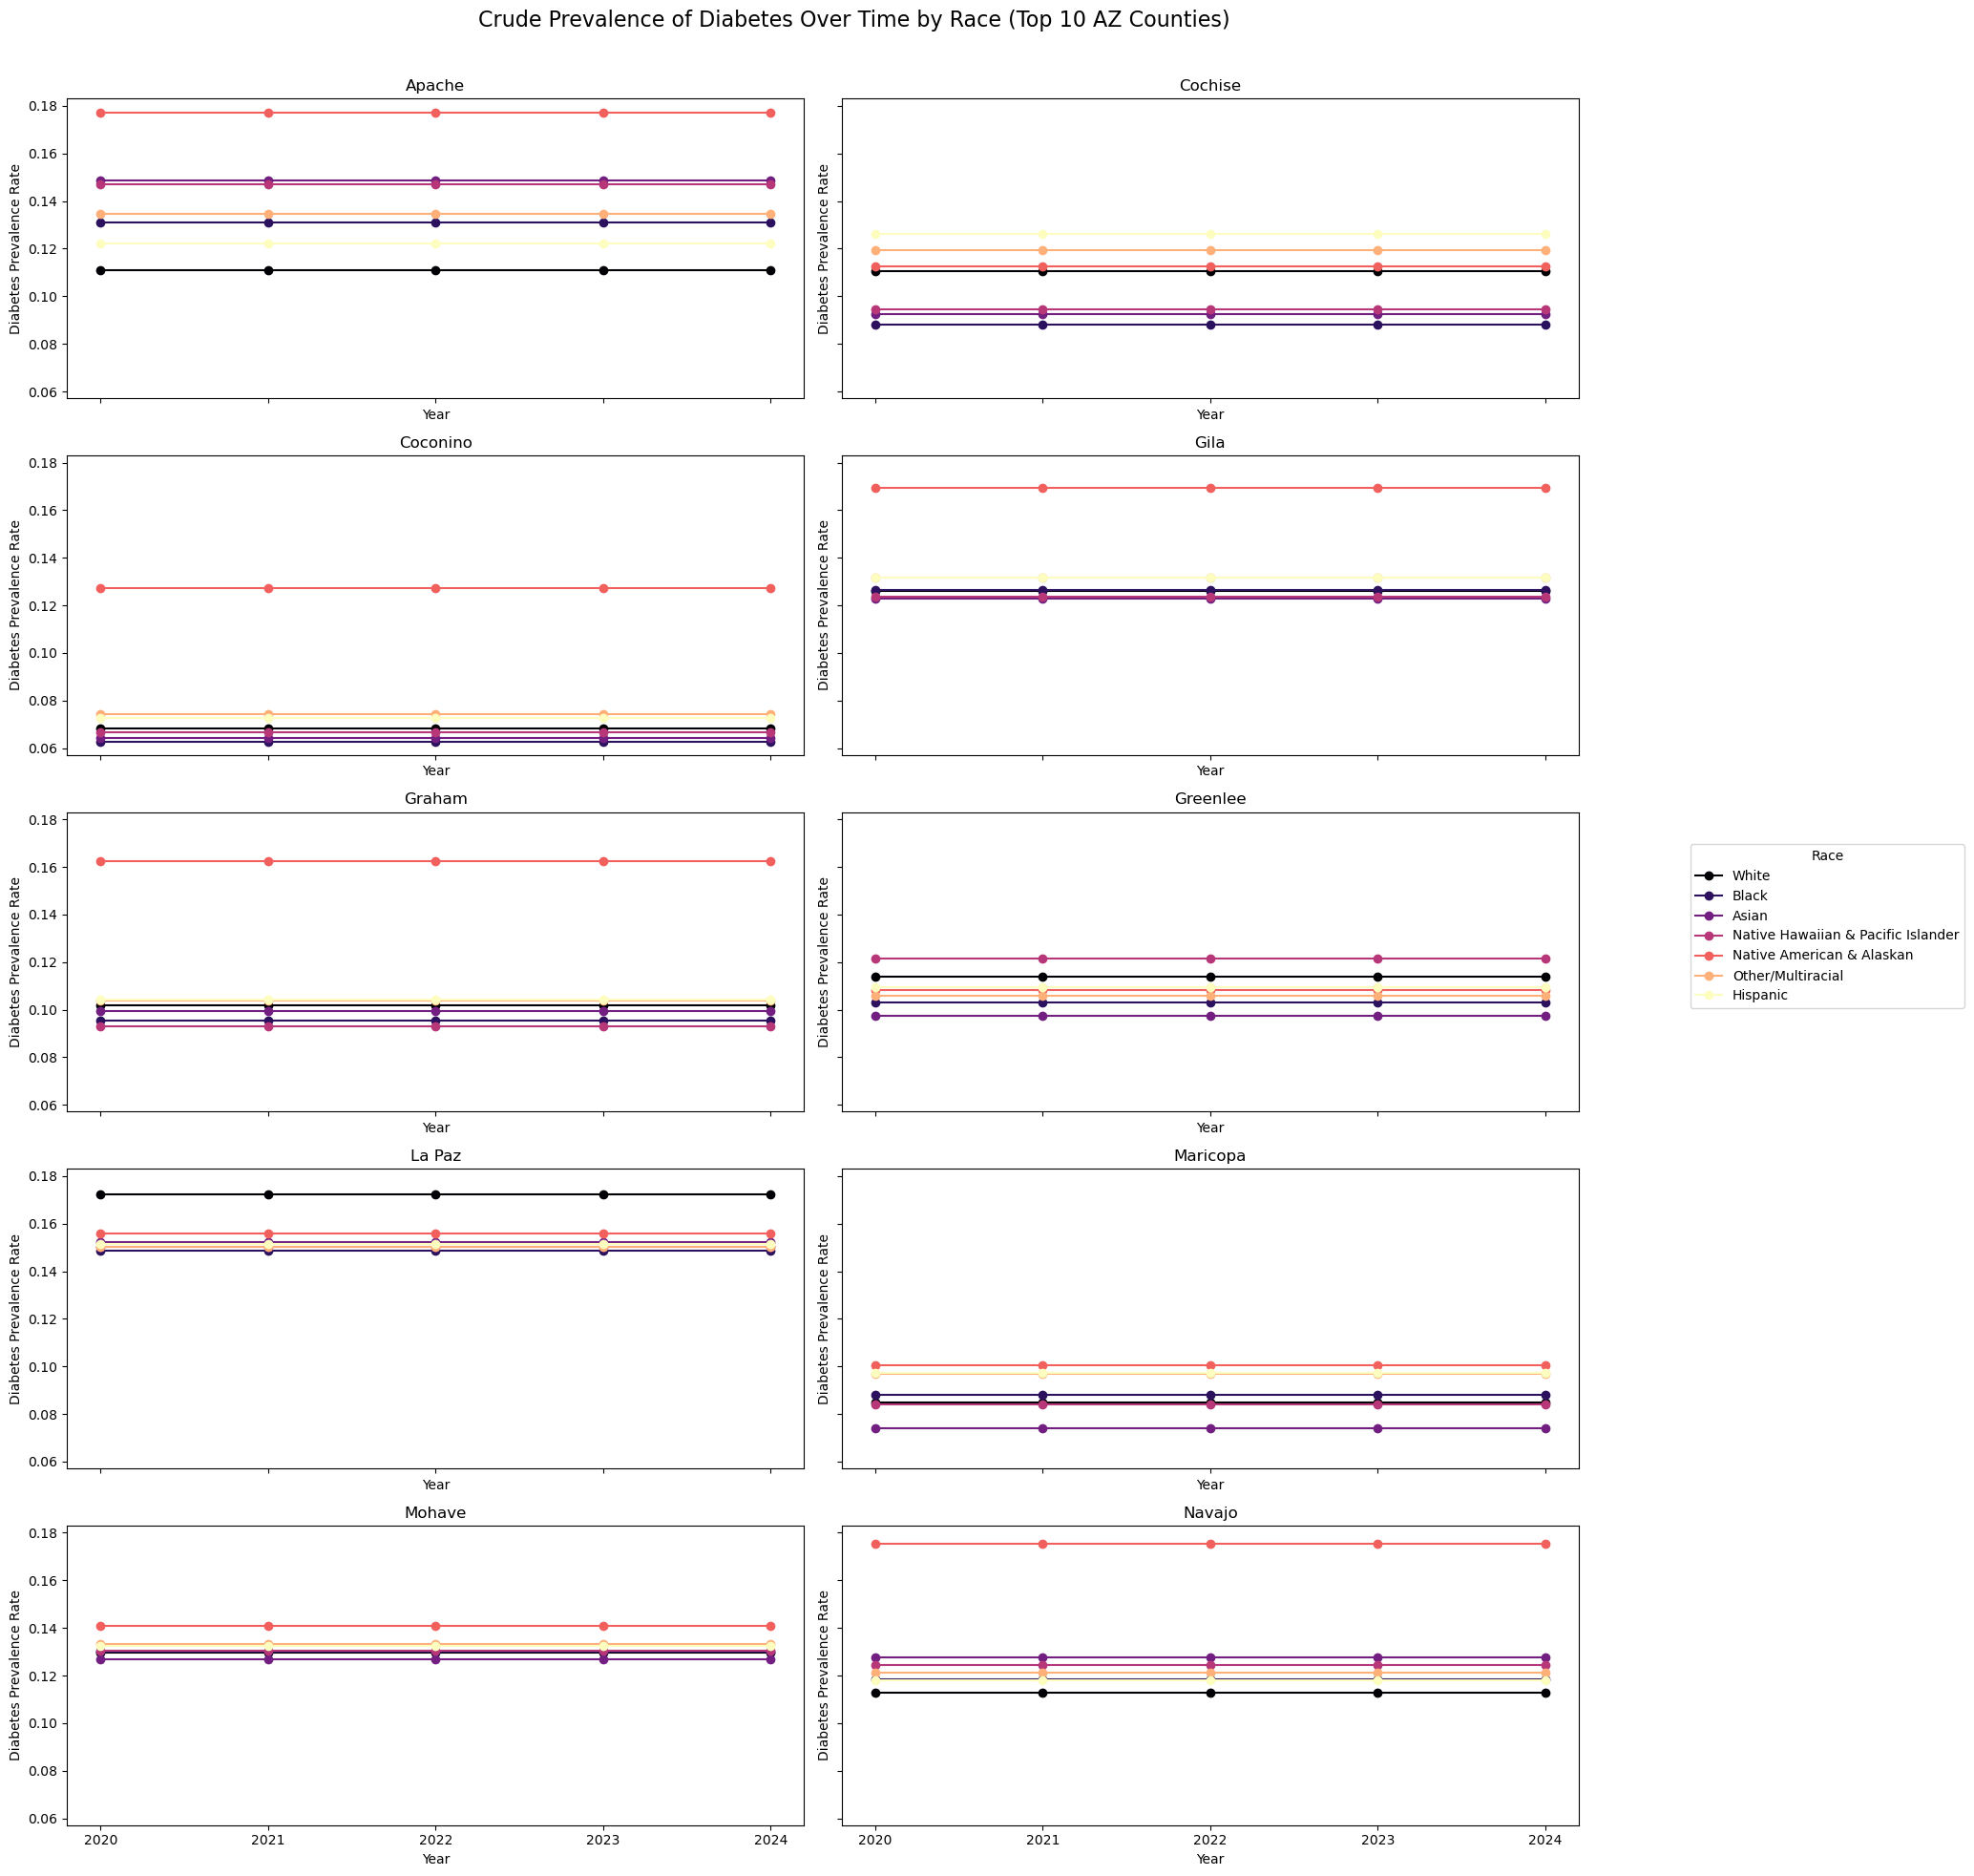

In [ ]:
import matplotlib.cm as cm

# Diabetes first
# Define top 10 counties
counties = [
    'Apache', 'Cochise', 'Coconino', 'Gila', 'Graham',
    'Greenlee', 'La Paz', 'Maricopa', 'Mohave', 'Navajo'
]

# Define races
race_columns = {
    '%WhiteDiabetes': 'White',
    '%BlackDiabetes': 'Black',
    '%AsianDiabetes': 'Asian',
    '%NHOPIDiabetes': 'Native Hawaiian & Pacific Islander',
    '%AIANDiabetes': 'Native American & Alaskan',
    '%OMultirDiabetes': 'Other/Multiracial',
    '%HispanicDiabetes': 'Hispanic'
}

# Some fun color stuff 
cmap = plt.colormaps.get_cmap('magma').resampled(len(race_columns))
colors = [cmap(i) for i in range(len(race_columns))]

# Create subplot grid
fig, axes = plt.subplots(5, 2, figsize=(18, 20), sharex=True, sharey=True)
axes = axes.flatten()

for idx, county in enumerate(counties):
    ax = axes[idx]
    subset = Unioned_Data_By_Race[Unioned_Data_By_Race['CountyName'] == county]
    years = subset['year'].values

    for (col, label), color in zip(race_columns.items(), colors):
        ax.plot(years, subset[col].values, label=label, color=color, marker='o')

    ax.set_title(f'{county}', fontsize=12)
    ax.set_xlabel('Year')
    ax.set_ylabel('Diabetes Prevalence Rate')

# Create single legend on the side
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title='Race', loc='center right', bbox_to_anchor=(1.15, 0.5))

plt.suptitle('Crude Prevalence of Diabetes Over Time by Race (Top 10 AZ Counties)', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.93, 0.97])  # adjusts space for legend and title
plt.show()

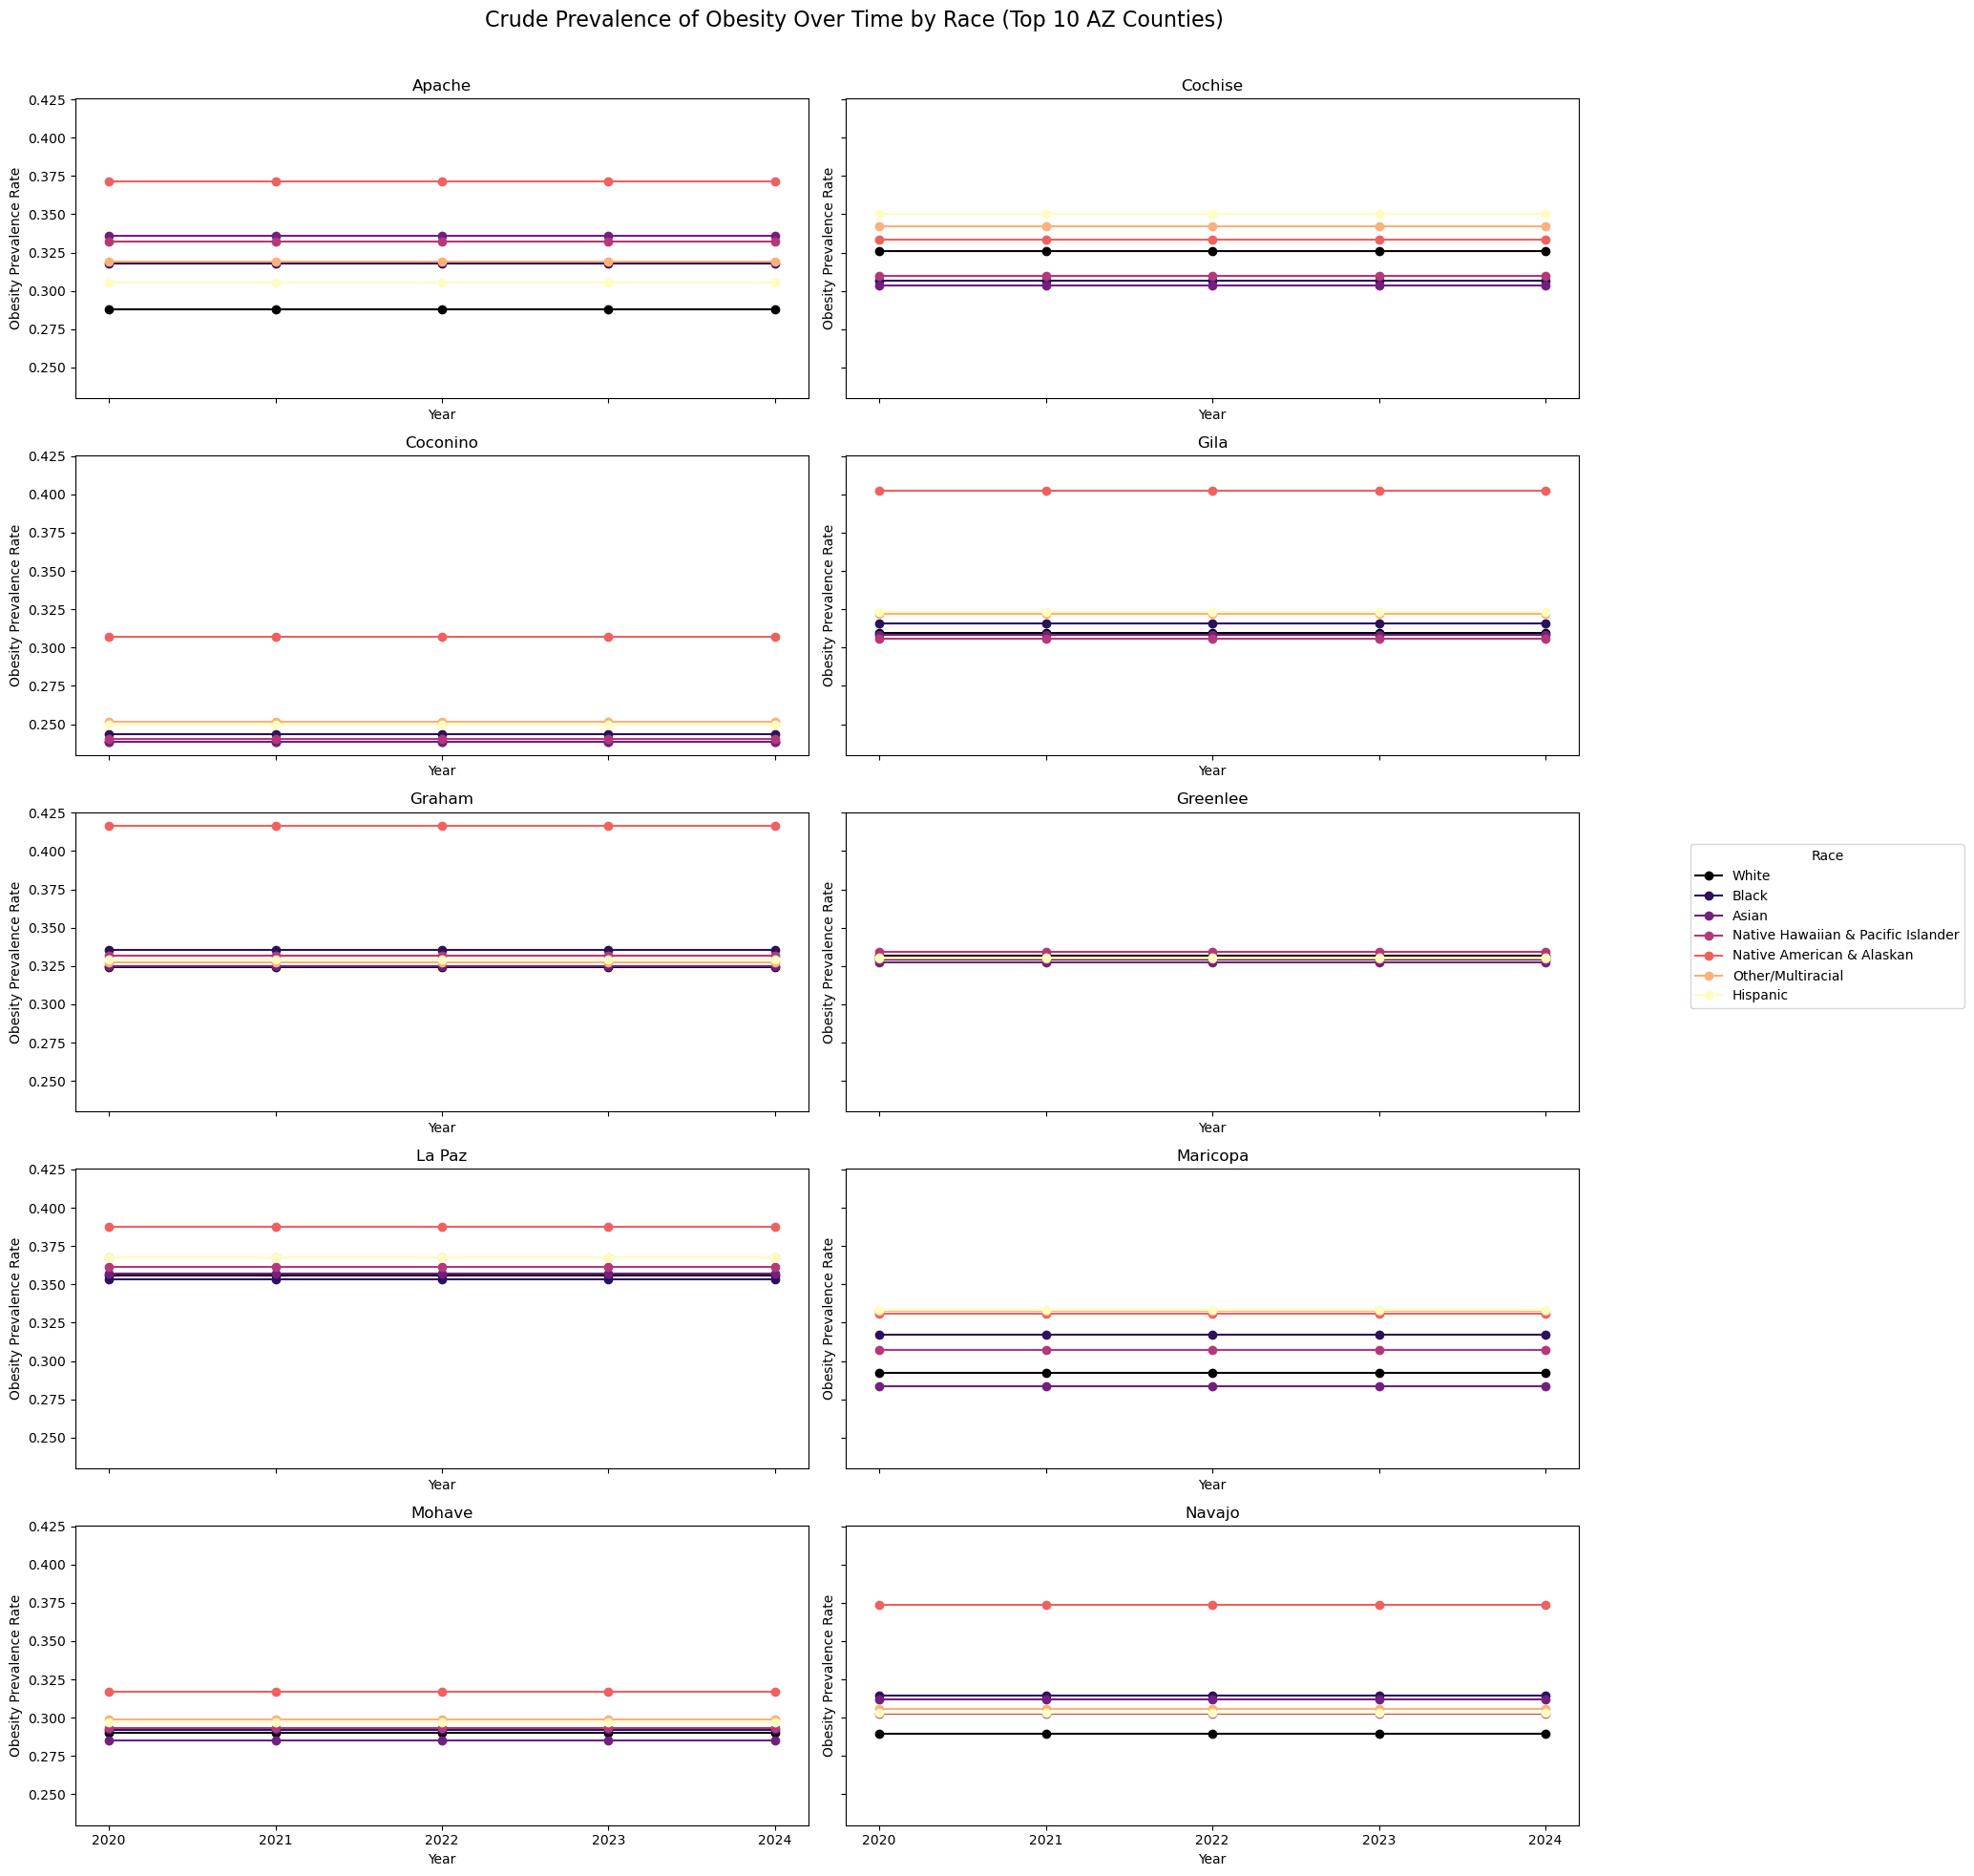

In [18]:
# Obesity Plots Next 

# Define top 10 counties
counties = [
    'Apache', 'Cochise', 'Coconino', 'Gila', 'Graham',
    'Greenlee', 'La Paz', 'Maricopa', 'Mohave', 'Navajo'
]

# Define races
race_columns = {
    '%WhiteObesity': 'White',
    '%BlackObesity': 'Black',
    '%AsianObesity': 'Asian',
    '%NHOPIObesity': 'Native Hawaiian & Pacific Islander',
    '%AIANObesity': 'Native American & Alaskan',
    '%OMultirObesity': 'Other/Multiracial',
    '%HispanicObesity': 'Hispanic'
}

# Some fun color stuff 
cmap = plt.colormaps.get_cmap('magma').resampled(len(race_columns))
colors = [cmap(i) for i in range(len(race_columns))]

# Create subplot grid
fig, axes = plt.subplots(5, 2, figsize=(18, 20), sharex=True, sharey=True)
axes = axes.flatten()

for idx, county in enumerate(counties):
    ax = axes[idx]
    subset = Unioned_Data_By_Race[Unioned_Data_By_Race['CountyName'] == county]
    years = subset['year'].values

    for (col, label), color in zip(race_columns.items(), colors):
        ax.plot(years, subset[col].values, label=label, color=color, marker='o')

    ax.set_title(f'{county}', fontsize=12)
    ax.set_xlabel('Year')
    ax.set_ylabel('Obesity Prevalence Rate')

# Create single legend on the side
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title='Race', loc='center right', bbox_to_anchor=(1.15, 0.5))

plt.suptitle('Crude Prevalence of Obesity Over Time by Race (Top 10 AZ Counties)', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.93, 0.97])  # adjusts space for legend and title
plt.show()

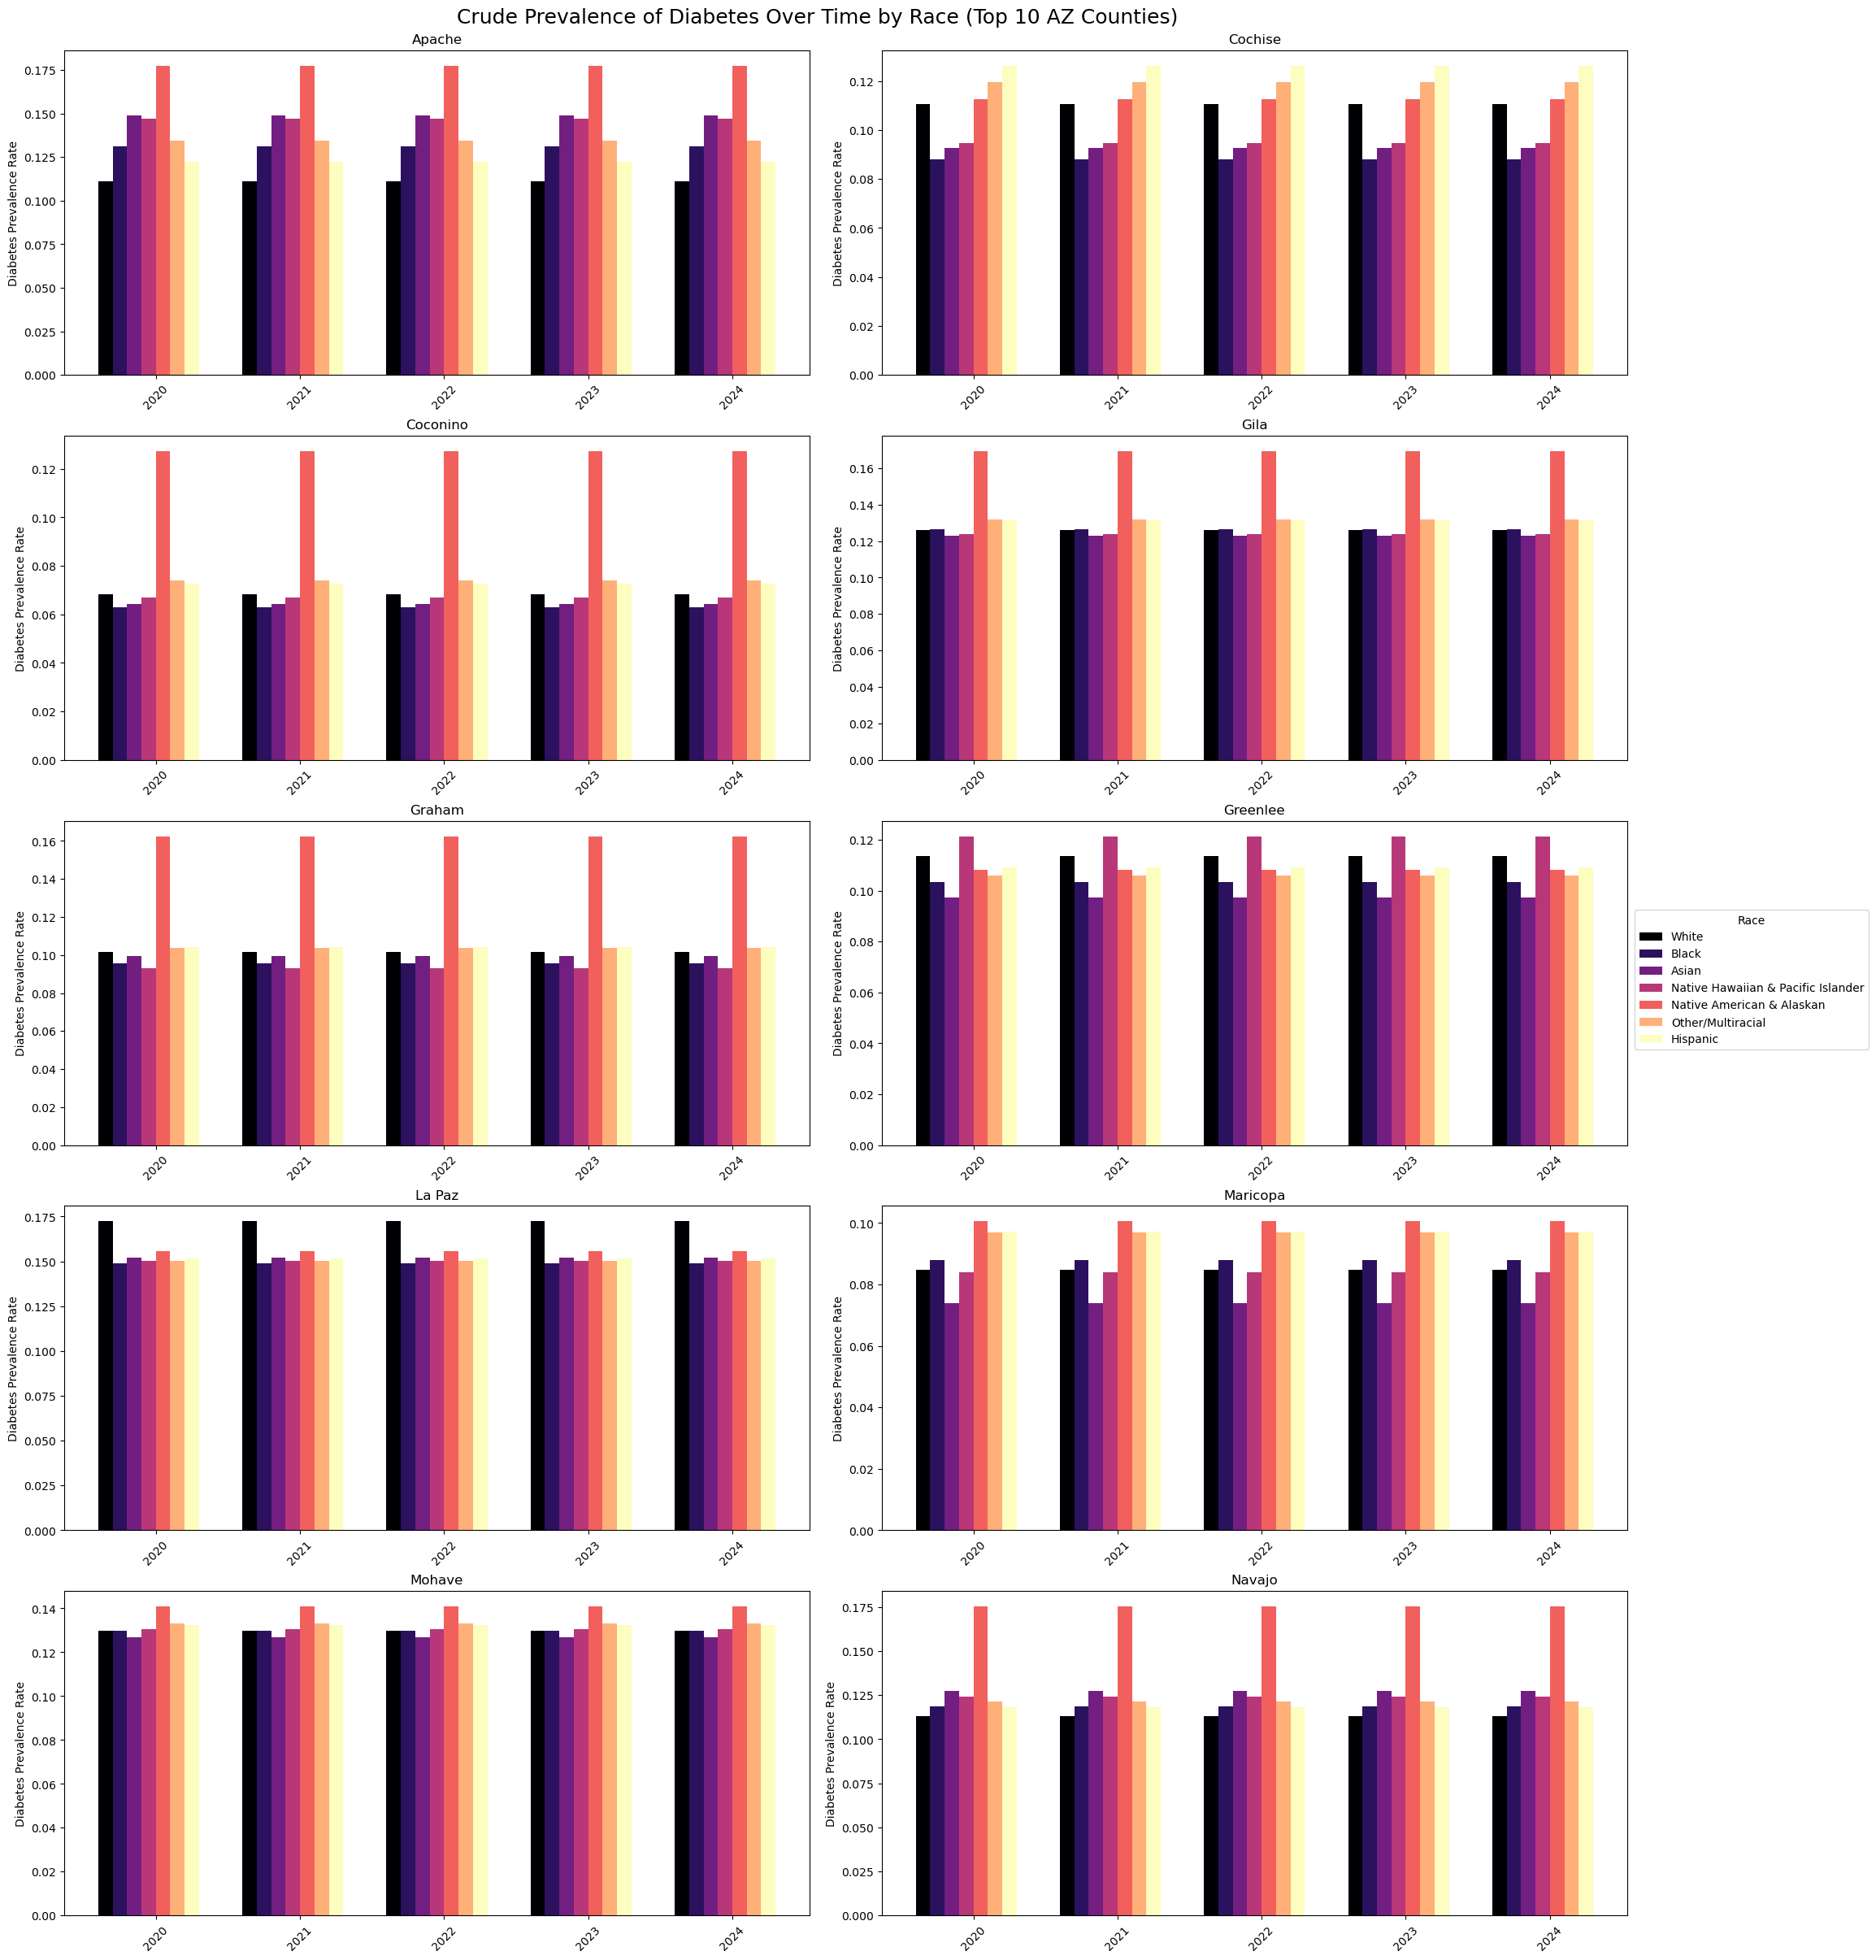

In [ ]:
# Test bar plot instead?

# Bar for Diabetes 
# Define top 10 counties
counties = [
    'Apache', 'Cochise', 'Coconino', 'Gila', 'Graham',
    'Greenlee', 'La Paz', 'Maricopa', 'Mohave', 'Navajo'
]

# Define race columns
race_columns = {
    '%WhiteDiabetes': 'White',
    '%BlackDiabetes': 'Black',
    '%AsianDiabetes': 'Asian',
    '%NHOPIDiabetes': 'Native Hawaiian & Pacific Islander',
    '%AIANDiabetes': 'Native American & Alaskan',
    '%OMultirDiabetes': 'Other/Multiracial',
    '%HispanicDiabetes': 'Hispanic'
}

# Set up color map
cmap = plt.colormaps.get_cmap('magma').resampled(len(race_columns))
colors = [cmap(i) for i in range(len(race_columns))]

# Setup the subplot grid
fig, axes = plt.subplots(5, 2, figsize=(20, 24), constrained_layout=True)
axes = axes.flatten()
bar_width = 0.1

for idx, county in enumerate(counties):
    ax = axes[idx]
    subset = Unioned_Data_By_Race[Unioned_Data_By_Race['CountyName'] == county]
    years = subset['year'].values

    # X positions for each year
    x = np.arange(len(years))

    for i, (col, label) in enumerate(race_columns.items()):
        heights = subset[col].values
        offsets = x + (i - len(race_columns)/2) * bar_width
        ax.bar(offsets, heights, width=bar_width, color=colors[i], label=label)

    ax.set_title(f'{county}', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45)
    ax.set_ylabel('Diabetes Prevalence Rate')

# One legend for all plots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title='Race', loc='center right', bbox_to_anchor=(1.15, 0.5))

plt.suptitle('Crude Prevalence of Diabetes Over Time by Race (Top 10 AZ Counties)', fontsize=18)
plt.show()


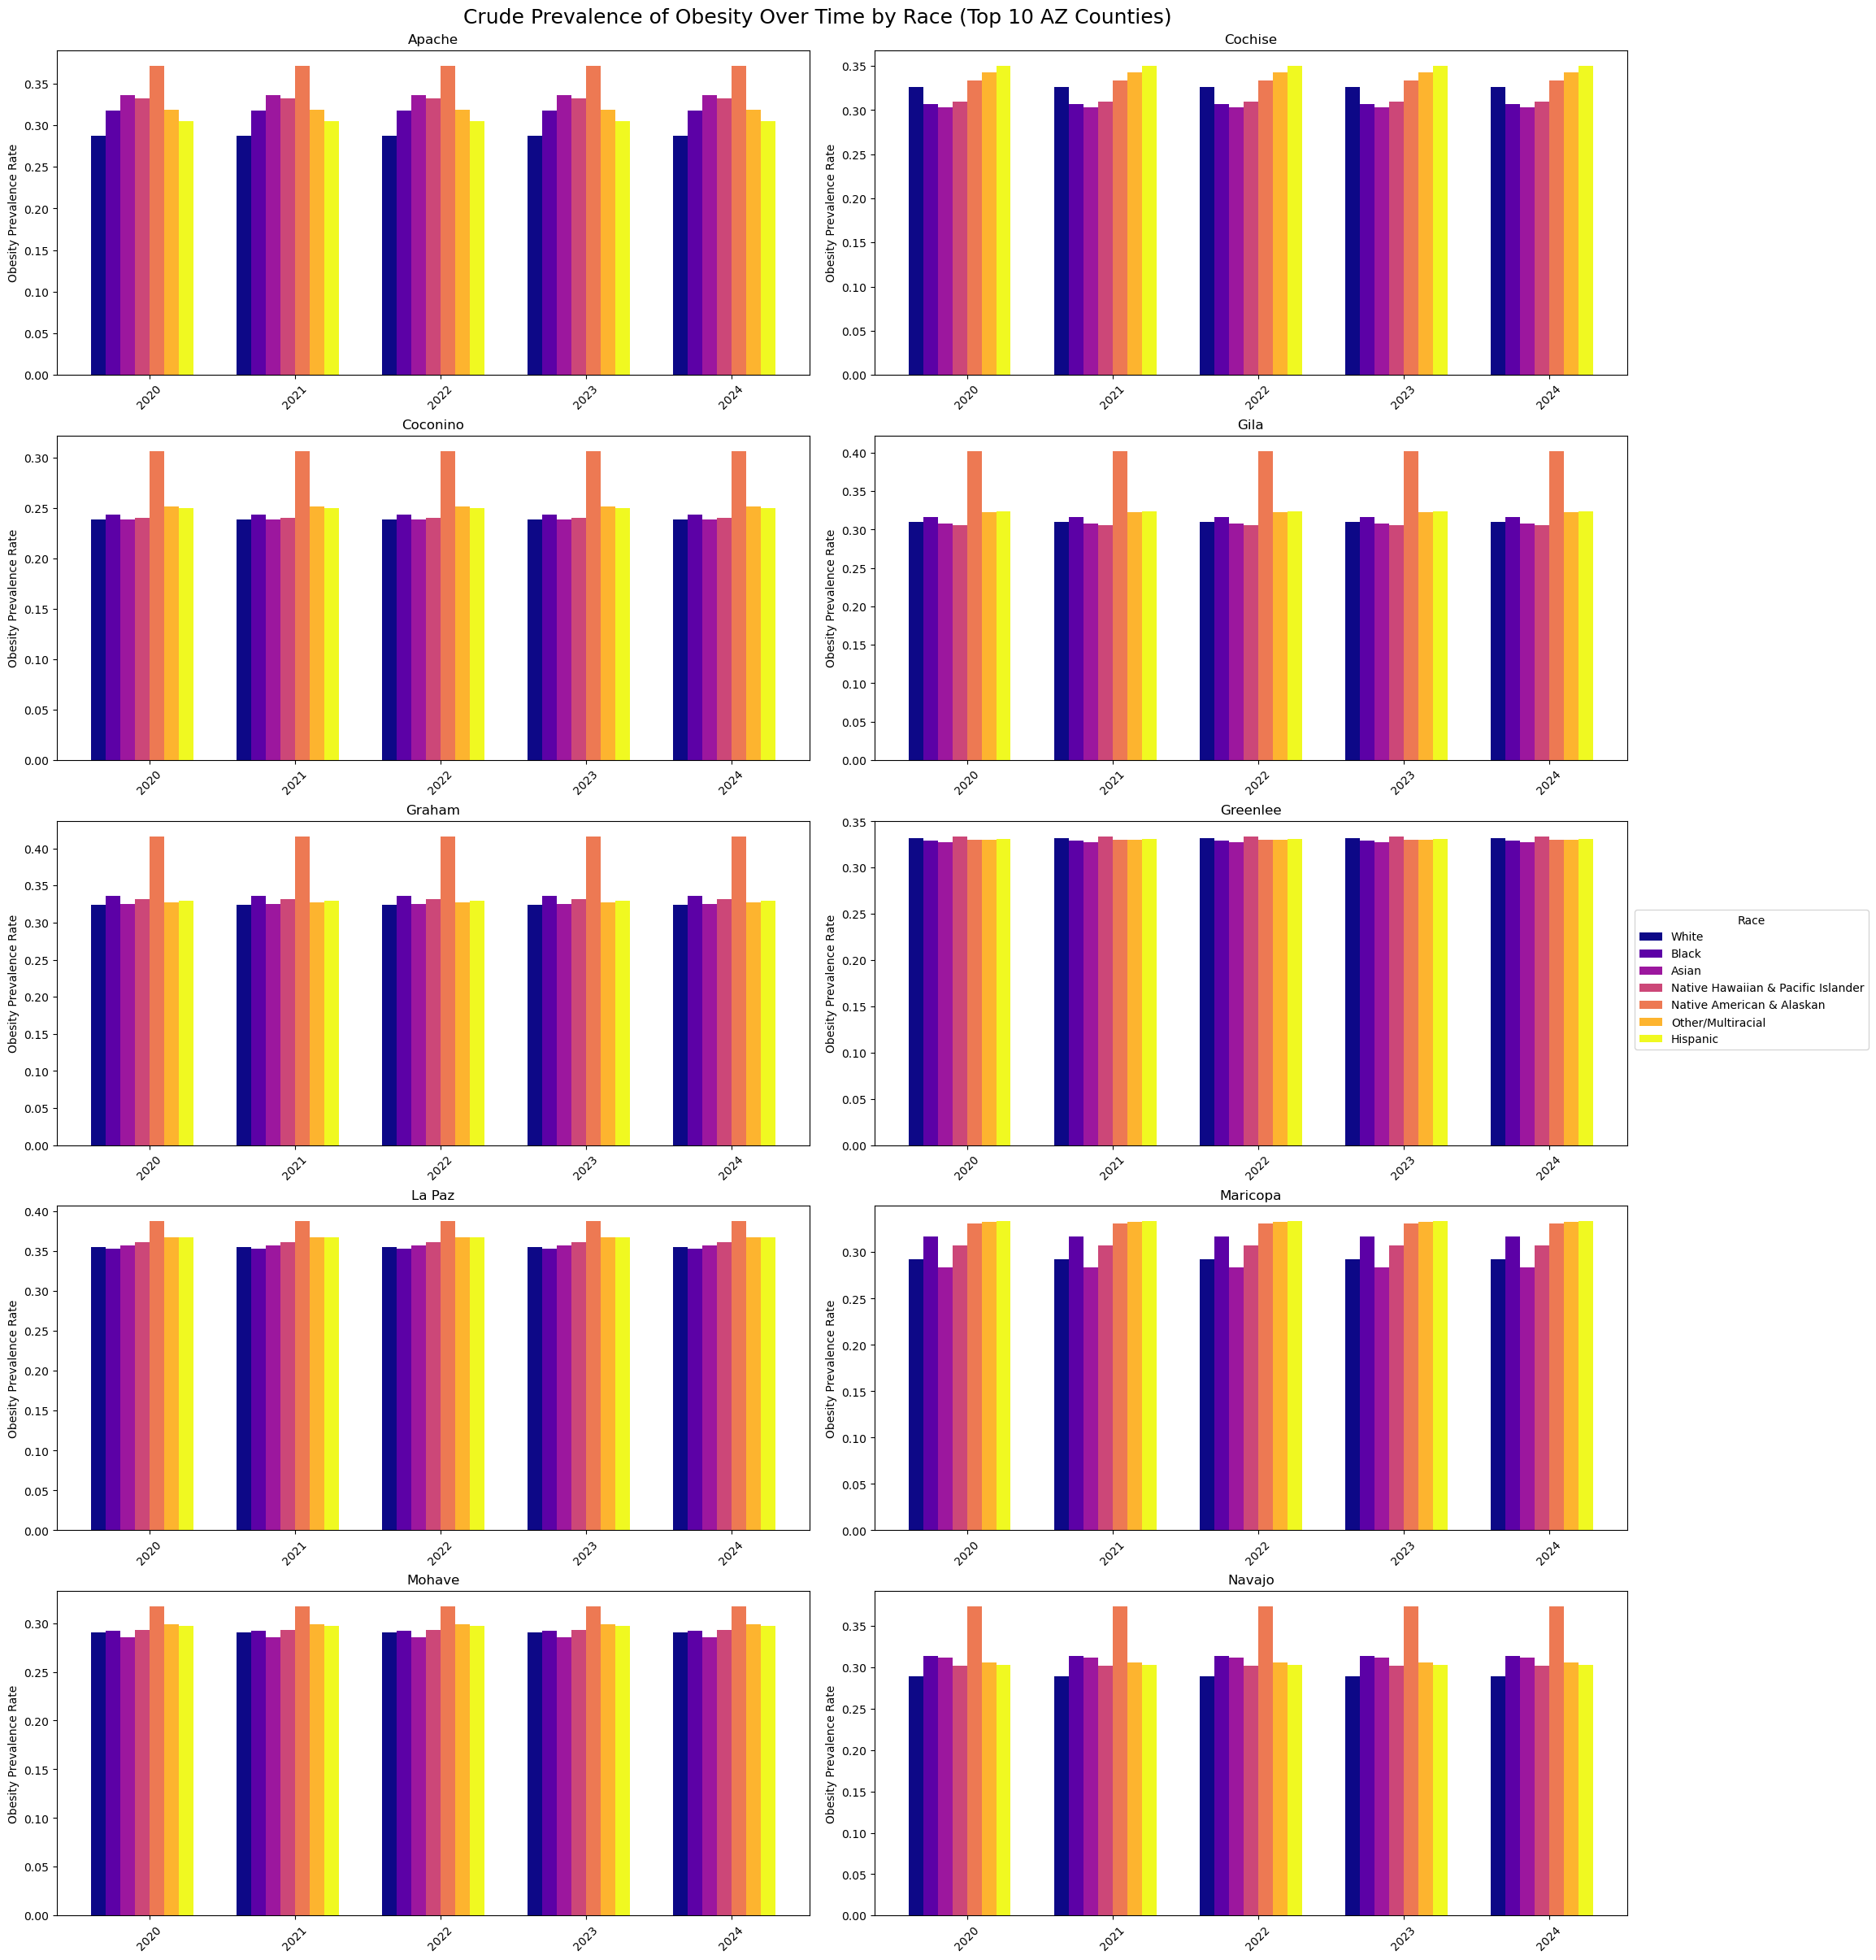

In [ ]:
# Bar for Obesity 

# Define top 10 counties
counties = [
    'Apache', 'Cochise', 'Coconino', 'Gila', 'Graham',
    'Greenlee', 'La Paz', 'Maricopa', 'Mohave', 'Navajo'
]

# Define race columns for obesity
obesity_columns = {
    '%WhiteObesity': 'White',
    '%BlackObesity': 'Black',
    '%AsianObesity': 'Asian',
    '%NHOPIObesity': 'Native Hawaiian & Pacific Islander',
    '%AIANObesity': 'Native American & Alaskan',
    '%OMultirObesity': 'Other/Multiracial',
    '%HispanicObesity': 'Hispanic'
}

# Set up color map
cmap = plt.colormaps.get_cmap('plasma').resampled(len(obesity_columns))
colors = [cmap(i) for i in range(len(obesity_columns))]

# Setup the subplot grid
fig, axes = plt.subplots(5, 2, figsize=(20, 24), constrained_layout=True)
axes = axes.flatten()
bar_width = 0.1

for idx, county in enumerate(counties):
    ax = axes[idx]
    subset = Unioned_Data_By_Race[Unioned_Data_By_Race['CountyName'] == county]
    years = subset['year'].values
    x = np.arange(len(years))

    for i, (col, label) in enumerate(obesity_columns.items()):
        heights = subset[col].values
        offsets = x + (i - len(obesity_columns)/2) * bar_width
        ax.bar(offsets, heights, width=bar_width, color=colors[i], label=label)

    ax.set_title(f'{county}', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45)
    ax.set_ylabel('Obesity Prevalence Rate')

# Shared legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title='Race', loc='center right', bbox_to_anchor=(1.15, 0.5))

plt.suptitle('Crude Prevalence of Obesity Over Time by Race (Top 10 AZ Counties)', fontsize=18)
plt.show()


In [ ]:
# Work with Cole's df and the food desert score from FARA
# Make sure both are strings
FARA["CountyName"] = FARA["CountyName"].astype(str).str.strip()
Unioned_Data_By_Race.loc["CountyName"] = Unioned_Data_By_Race["CountyName"].astype(str).str.strip()

# Merge
merged_df = Unioned_Data_By_Race.merge(
    FARA[["CountyName", "food_desert_score"]],
    on="CountyName",
    how="left"
)

merged_df.head()

/var/folders/98/btdxv4ms70376jpvysf0g5sh0000gn/T/ipykernel_74590/286714994.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Unioned_Data_By_Race.loc["CountyName"] = Unioned_Data_By_Race["CountyName"].astype(str).str.strip()


,CountyName,year,%WhiteDiabetes,%WhiteObesity,%BlackDiabetes,%BlackObesity,%AsianDiabetes,%AsianObesity,%NHOPIDiabetes,%NHOPIObesity,%AIANDiabetes,%AIANObesity,%OMultirDiabetes,%OMultirObesity,%HispanicDiabetes,%HispanicObesity,food_desert_score
0,Apache,2020,0.111111,0.287668,0.131051,0.31804,0.148798,0.336039,0.147077,0.332077,0.177325,0.371487,0.134515,0.319048,0.122297,0.30519,7.0
1,Apache,2020,0.111111,0.287668,0.131051,0.31804,0.148798,0.336039,0.147077,0.332077,0.177325,0.371487,0.134515,0.319048,0.122297,0.30519,7.0
2,Apache,2020,0.111111,0.287668,0.131051,0.31804,0.148798,0.336039,0.147077,0.332077,0.177325,0.371487,0.134515,0.319048,0.122297,0.30519,5.0
3,Apache,2020,0.111111,0.287668,0.131051,0.31804,0.148798,0.336039,0.147077,0.332077,0.177325,0.371487,0.134515,0.319048,0.122297,0.30519,7.0
4,Apache,2020,0.111111,0.287668,0.131051,0.31804,0.148798,0.336039,0.147077,0.332077,0.177325,0.371487,0.134515,0.319048,0.122297,0.30519,2.0


/var/folders/98/btdxv4ms70376jpvysf0g5sh0000gn/T/ipykernel_74590/3301945447.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(outcome_columns))


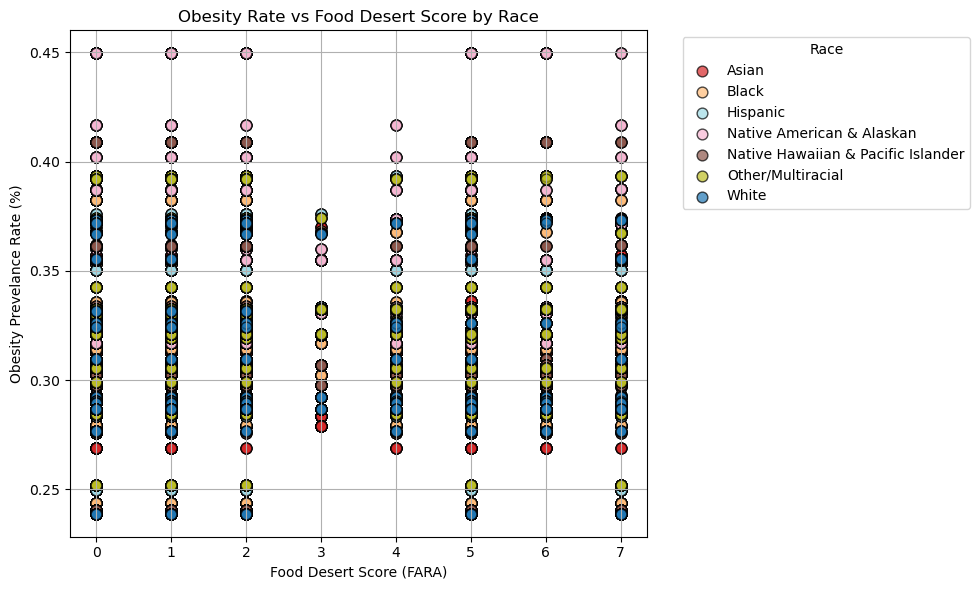

In [63]:
# Sort outcomes with races -- Obesity 
outcome_columns = {
    '%WhiteObesity': 'White',
    '%BlackObesity': 'Black',
    '%AsianObesity': 'Asian',
    '%NHOPIObesity': 'Native Hawaiian & Pacific Islander',
    '%AIANObesity': 'Native American & Alaskan',
    '%OMultirObesity': 'Other/Multiracial',
    '%HispanicObesity': 'Hispanic'
}

# Use long format
long_df = merged_df.melt(
    id_vars=["food_desert_score", "CountyName", "year"],
    value_vars=list(outcome_columns.keys()),
    var_name="ObesityColumn",
    value_name="ObesityRate"
)

# Add race labels
long_df["Race"] = long_df["ObesityColumn"].map(outcome_columns)

# Plot
plt.figure(figsize=(10, 6))
cmap = cm.get_cmap("tab20", len(outcome_columns))
colors = [cmap(i) for i in range(len(outcome_columns))]
race_to_color = dict(zip(outcome_columns.values(), colors))

for race, group in long_df.groupby("Race"):
    plt.scatter(
        group["food_desert_score"],
        group["ObesityRate"],
        label=race,
        color=race_to_color[race],
        alpha=0.7,
        edgecolor="k",
        s=60
    )

plt.xlabel("Food Desert Score (FARA)")
plt.ylabel("Obesity Prevelance Rate (%)")
plt.title("Obesity Rate vs Food Desert Score by Race")
plt.legend(title="Race", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/98/btdxv4ms70376jpvysf0g5sh0000gn/T/ipykernel_74590/1581798996.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(outcome_columns))


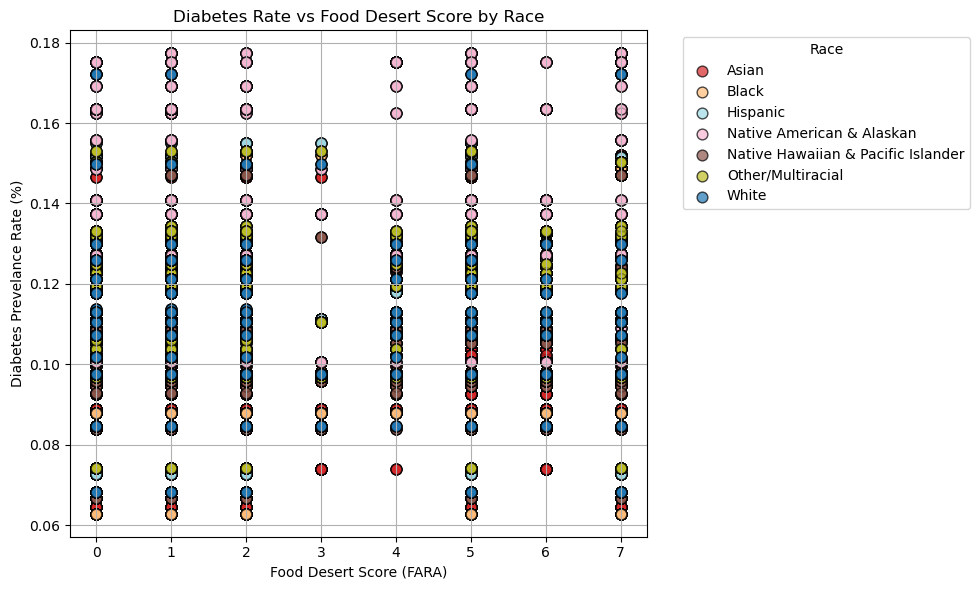

In [64]:
# Sort outcomes with races -- Diabetes
outcome_columns = {
    '%WhiteDiabetes': 'White',
    '%BlackDiabetes': 'Black',
    '%AsianDiabetes': 'Asian',
    '%NHOPIDiabetes': 'Native Hawaiian & Pacific Islander',
    '%AIANDiabetes': 'Native American & Alaskan',
    '%OMultirDiabetes': 'Other/Multiracial',
    '%HispanicDiabetes': 'Hispanic'
}

# Use long format
long_df = merged_df.melt(
    id_vars=["food_desert_score", "CountyName", "year"],
    value_vars=list(outcome_columns.keys()),
    var_name="DiabetesColumn",
    value_name="DiabetesRate"
)

# Add race labels
long_df["Race"] = long_df["DiabetesColumn"].map(outcome_columns)

# Plot
plt.figure(figsize=(10, 6))
cmap = cm.get_cmap("tab20", len(outcome_columns))
colors = [cmap(i) for i in range(len(outcome_columns))]
race_to_color = dict(zip(outcome_columns.values(), colors))

for race, group in long_df.groupby("Race"):
    plt.scatter(
        group["food_desert_score"],
        group["DiabetesRate"],
        label=race,
        color=race_to_color[race],
        alpha=0.7,
        edgecolor="k",
        s=60
    )

plt.xlabel("Food Desert Score (FARA)")
plt.ylabel("Diabetes Prevelance Rate (%)")
plt.title("Diabetes Rate vs Food Desert Score by Race")
plt.legend(title="Race", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()